# Preprocessing and merging trip data with maintenance records

In [897]:
import pandas as pd
from pathlib import Path
import os
import numpy as np
from geopy.distance import geodesic
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from lifelines import WeibullFitter
import math
import numpy as np
import pandas as pd
import folium
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
import datetime

In [898]:
mechanical_damages = [
    'Bremse(r)',                   # Brakes (Physical wear)
    'Brake(s) need adjustment',    # Brakes (Cable stretch/wear)
    'Hjul',                        # Wheels (Impact/wear)
    'Lite luft',                   # Low Air (Punctures/Valve leaks)
    'Gir',                         # Gears (Mechanical wear)
    'Belte / Belt',                # Drive Belt (Friction wear)
    'Pedaler',                     # Pedals (Bearings/Impact)
    'Cranck bearing/bottom bracket ', # Cranks (Bearing fatigue)
    'Styre',                       # Handlebar (Impact/Fatigue)
    'Styrelager',                  # Headset Bearings (Vibration)
    'Sete',                        # Seat (Physical damage)
    'Setepinneklemme',             # Seat Clamp (Mechanical stress)
    'Støtte',                      # Kickstand (Spring/Hinge wear)
    'Skjerm(er)',                  # Fenders (Vibration/Impact)
    'Ringeklokke',                 # Bell (Mechanical spring)
    'Basket',                      # Basket (Load/Impact)
    'Lys',                         # Lights (Vibration/Wiring fatigue)
    'Frame'                        # Frame (Structural stress)
]

system_damages = [
    'Unresponsive Controller',     # Connectivity/Firmware (The big one)
    'Too many quick returns',      # User Behavior/System Flag
    'Unauthorized Trip',           # System/Theft Flag
    'Lock & unlock',               # Smart Lock Actuator/Comms
    'Lås',                         # Smart Lock Hardware
    'Console',                     # Dashboard Electronics
    'GPS',                         # Connectivity/Module
    'Battery',                     # Charging/BMS (Time + Cycles)
    'Vandalism'                    # External Factor (Scales with Time on Street)
]

# Loading raw data

In [899]:
from pathlib import Path
import os
import pandas as pd
from tabulate import tabulate

# ----------------------------
# Directories setup
# ----------------------------
notebook_dir = Path(os.getcwd())
trip_base_dir = notebook_dir / "trip_data" / "raw_files"
trip_year_folders = sorted(trip_base_dir.glob("trondheimbysykkel-*"))
raw_maintenance_files_dir = notebook_dir / "maintenance_data" / "raw_files"
_maintenance_files = sorted(raw_maintenance_files_dir.glob("*.csv"))

# ----------------------------
# Load Trip Data by Year
# ----------------------------
trip_data_list = []

for folder in trip_year_folders:
    parquet_files = sorted(folder.glob("*.parquet"))
    
    # Load and collect dataframes
    if parquet_files:
        year_dfs = [pd.read_parquet(file) for file in parquet_files]
        trip_data_list.append(pd.concat(year_dfs, ignore_index=True))

# ----------------------------
# Combine into master trip_data
# ----------------------------
trip_data = pd.concat(trip_data_list, ignore_index=True) if trip_data_list else pd.DataFrame()

# ----------------------------
# Single Clean Summary
# ----------------------------
final_summary = [
    ["Trip year folders", len(trip_year_folders)],
    ["Maintenance files", len(_maintenance_files)],
    ["Total Rows", f"{len(trip_data):,}"],
    ["Total Columns", trip_data.shape[1]],
]

print("\nLOAD COMPLETE")
print(tabulate(final_summary, headers=["Metric", "Value"], tablefmt="github"))


LOAD COMPLETE
| Metric            | Value      |
|-------------------|------------|
| Trip year folders | 3          |
| Maintenance files | 3          |
| Total Rows        | 19,339,524 |
| Total Columns     | 24         |


In [900]:
# --- Load Maintenance Data ---
maint_store = {'damage': [], 'repair': [], 'maintenance': []}

for file in _maintenance_files:
    df = pd.read_csv(file)
    fname = file.name.lower()
    
    # Sort into correct bucket based on filename
    category = 'damage' if 'damage' in fname else 'repair' if 'repair' in fname else 'maintenance'
    maint_store[category].append(df)

# Create DataFrames dynamically
damage_data = pd.concat(maint_store['damage'], ignore_index=True) if maint_store['damage'] else pd.DataFrame()
repair_data = pd.concat(maint_store['repair'], ignore_index=True) if maint_store['repair'] else pd.DataFrame()
maintenance_data = pd.concat(maint_store['maintenance'], ignore_index=True) if maint_store['maintenance'] else pd.DataFrame()

# Concise, pretty summary
stats = [
    ["Damage Logs", f"{len(damage_data):,}"],
    ["Repair Logs", f"{len(repair_data):,}"],
    ["Maint Logs",  f"{len(maintenance_data):,}"]
]

print("\n" + "="*30)
print(tabulate(stats, headers=["Dataset", "Rows"], tablefmt="github"))
print("="*30)


| Dataset     | Rows    |
|-------------|---------|
| Damage Logs | 756,565 |
| Repair Logs | 250,815 |
| Maint Logs  | 363,324 |


# Converting data types

In [901]:
print("\nCleaning time columns and optimizing ID types...")

# 1. Configuration: (DataFrame, Date Columns, Sort Column)
cleaning_map = [
    (trip_data,        ['position_at', 'trip_started_at', 'trip_ended_at'], 'trip_started_at'),
    (damage_data,      ['created_at', 'resolved_at'],                      'created_at'),
    (maintenance_data, ['started_at', 'completed_at'],                     'completed_at'),
    (repair_data,      ['created_at', 'started_at', 'completed_at'],       'completed_at')
]

for df, date_cols, sort_col in cleaning_map:
    if df is not None and not df.empty:
        # Convert Dates: timezone-naive nanosecond precision
        for col in date_cols:
            if col in df.columns:
                df[col] = pd.to_datetime(df[col], errors='coerce').dt.tz_localize(None).astype('datetime64[ns]')
        
        # Optimize IDs: Find 'id' columns and convert to Int64 (handles NaNs better than int)
        id_cols = [c for c in df.columns if 'id' in c.lower()]
        for c in id_cols:
            df[c] = pd.to_numeric(df[c], errors='coerce').astype('Int64')
            
        # Sort for merge_asof readiness
        df.sort_values(['vehicle_id', sort_col], inplace=True)

# --- Concise Type Summary ---
type_stats = [
    ["Trips", f"{trip_data.shape[0]:,}", "trip_started_at"],
    ["Damage", f"{damage_data.shape[0]:,}", "created_at"],
    ["Maint", f"{maintenance_data.shape[0]:,}", "completed_at"],
    ["Repair", f"{repair_data.shape[0]:,}", "completed_at"]
]

print("\n" + "="*50)
print(tabulate(type_stats, headers=["Dataset", "Rows", "Sorted By"], tablefmt="github"))
print("="*50)
print("SUCCESS: All time columns localized and ID columns optimized.")


Cleaning time columns and optimizing ID types...

| Dataset   | Rows       | Sorted By       |
|-----------|------------|-----------------|
| Trips     | 19,339,524 | trip_started_at |
| Damage    | 756,565    | created_at      |
| Maint     | 363,324    | completed_at    |
| Repair    | 250,815    | completed_at    |
SUCCESS: All time columns localized and ID columns optimized.


# Data processing and filtering data

In [902]:
# --- 2. TARGETED FILTERING (THE FIX) ---
TARGET_CASE = 'trondheim'
TARGET_YEARS = [2024, 2023] 

# Using a dictionary to explicitly update the variables and prevent column loss
to_filter = {
    'damage_data':      (damage_data,      'created_at',    'Damage Reports'),
    'maintenance_data': (maintenance_data, 'completed_at',  'Maintenance Jobs'),
    'repair_data':      (repair_data,      'completed_at',  'Repairs Logged'),
    'trip_data':        (trip_data,        'trip_ended_at', 'Total Trips')
}

filtered_results = []

for var_name, (df, date_col, label) in to_filter.items():
    if df is not None and not df.empty:
        mask = df[date_col].dt.year.isin(TARGET_YEARS)
        if 'case' in df.columns:
            mask &= (df['case'] == TARGET_CASE)
            
        # Explicit copy to preserve ALL columns (including damage_id)
        filtered_df = df[mask].copy()
        globals()[var_name] = filtered_df
        filtered_results.append([label, f"{len(filtered_df):,}"])

# Print Year/Case Status
years_str = ", ".join(map(str, TARGET_YEARS))
print(f"\n{'='*45}\n{TARGET_CASE.upper()} FLEET STATUS ({years_str})\n{'='*45}")
print(tabulate(filtered_results, headers=["Dataset", "Count"], tablefmt="github"))


TRONDHEIM FLEET STATUS (2024, 2023)
| Dataset          | Count     |
|------------------|-----------|
| Damage Reports   | 65,202    |
| Maintenance Jobs | 38,684    |
| Repairs Logged   | 0         |
| Total Trips      | 9,620,493 |


## Drop columns

In [903]:
# drop columns in trip_data that are not needed
trip_data = trip_data.drop(columns=['position_wkt', 'trip_unlock_method', 'trip_end_dock_number', 'trip_start_dock_number', 'product_id', 'product_name', 'product_price', 'product_sales_channel', 'product_sales_locale', 'sale_from_value_code', 'user_id', 'trip_state'])

## Remove NULL on start or end station

In [904]:
# Print NULL values whole trip_data
print("\nNULL values in trip_data:")
null_start = trip_data['trip_start_dock_group_title'].isnull().sum()
null_end = trip_data['trip_end_dock_group_title'].isnull().sum()
print(f"- trip_start_dock_group_title: {null_start:,} NULLs")
print(f"- trip_end_dock_group_title: {null_end:,} NULLs")

# Remove rows with NULLs in critical columns (if any)
trip_data = trip_data.dropna(subset=['trip_start_dock_group_title', 'trip_end_dock_group_title'])


NULL values in trip_data:
- trip_start_dock_group_title: 0 NULLs
- trip_end_dock_group_title: 265,698 NULLs


## Filter out "unresponsive controller" outside operating hours

In [905]:
# 1. Pre-process and Identify
damage_data['created_hour'] = damage_data['created_at'].dt.hour
initial_count = len(damage_data)

# Define criteria for automated system noise
noise_types = ["Unresponsive Controller", "Unauthorized Trip"]
cutoff_time = datetime.time(6, 1, 0)

is_noise = (damage_data['damage_type_name'].isin(noise_types)) & \
           (damage_data['created_at'].dt.time < cutoff_time)

# 2. Filter 
removed_rows = damage_data[is_noise].copy()
damage_data = damage_data[~is_noise].copy()

# Print summary
cleanup_stats = [
    ["Initial Logs", f"{initial_count:,}"],
    ["System Noise Removed", f"{len(removed_rows):,}"],
    ["Cleaned Dataset", f"{len(damage_data):,}"]
]

print(f"\n{'='*40}\nNOISE CLEANUP: OVERNIGHT SYSTEM FLAGS\n{'='*40}")
print(tabulate(cleanup_stats, headers=["Metric", "Count"], tablefmt="github"))

if not removed_rows.empty:
    print(f"\nSAMPLE OF REMOVED NOISE (PRE-06:01):")
    print(removed_rows[['created_at', 'damage_type_name']].head(5).to_string(index=False))
print("="*40)


NOISE CLEANUP: OVERNIGHT SYSTEM FLAGS
| Metric               | Count   |
|----------------------|---------|
| Initial Logs         | 65,202  |
| System Noise Removed | 44,220  |
| Cleaned Dataset      | 20,982  |

SAMPLE OF REMOVED NOISE (PRE-06:01):
             created_at        damage_type_name
2023-06-20 05:00:03.696 Unresponsive Controller
2023-07-02 05:00:03.178 Unresponsive Controller
2023-07-04 05:00:03.129 Unresponsive Controller
2023-07-20 05:00:02.981 Unresponsive Controller
2023-07-21 05:00:02.070 Unresponsive Controller


## Remove duplicate lat/long records

GPS pings regularly and sometimes without bike movement. this code removes consequtive records that have identical long/lat

In [906]:
def haversine_distance(lat1, lon1, lat2, lon2):
    # Earth's radius in kilometers
    r = 6371 
    
    # Convert degrees to radians
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    
    # Apply formula
    a = np.sin(dphi/2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    
    return r * c # Returns distance in km

In [907]:
# --- Stationary Ping Cleanup ---
# 1. Prep: Sort and Shift
trip_data = trip_data.sort_values(['vehicle_id', 'position_at']).reset_index(drop=True)
grp = trip_data.groupby('vehicle_id')

trip_data['prev_time'] = grp['position_at'].shift(1)
trip_data['prev_trip_id'] = grp['trip_id'].shift(1)

# 2. Distance Calculation (meters)
trip_data['dist_from_prev_m'] = haversine_distance(
    trip_data['position_latitude'], trip_data['position_longitude'],
    grp['position_latitude'].shift(1), grp['position_longitude'].shift(1)
) * 1000

# 3. Identify and Remove
# Threshold set to 0.0 to catch only absolute duplicates; adjust to 5.0 for GPS jitter
GPS_NOISE_THRESHOLD_M = 0.0
is_stationary = (trip_data['trip_id'] == trip_data['prev_trip_id']) & \
                (trip_data['dist_from_prev_m'] <= GPS_NOISE_THRESHOLD_M)

rows_before = len(trip_data)
stat_rows = trip_data[is_stationary].copy()
trip_data = trip_data[~is_stationary].copy()

# --- Minimalist Summary ---
diffs = (stat_rows['position_at'] - stat_rows['prev_time']).dt.total_seconds()

stats = [
    ["Rows Before", f"{rows_before:,}"],
    ["Stationary Removed", f"{len(stat_rows):,}"],
    ["Rows After", f"{len(trip_data):,}"],
    ["Reduction %", f"{(1 - len(trip_data)/rows_before):.1%}"]
]

time_stats = [
    ["Mean Gap", f"{diffs.mean():.1f}s"],
    ["Median Gap", f"{diffs.median():.1f}s"],
    ["Max Gap", f"{diffs.max():.1f}s"]
]

print(f"\n{'='*35}\nSTATIONARY PING REMOVAL\n{'='*35}")
print(tabulate(stats, tablefmt="plain"))
print(f"\nTime Stats for Removed Pings:")
print(tabulate(time_stats, tablefmt="plain"))

if not stat_rows.empty:
    print(f"\nSample Data (First 5):")
    sample = stat_rows[['trip_id', 'position_at', 'dist_from_prev_m']].head(5)
    print(tabulate(sample, headers='keys', tablefmt="simple", showindex=False))
print("="*35)


STATIONARY PING REMOVAL
Rows Before         9,354,795
Stationary Removed  1,546,751
Rows After          7,808,044
Reduction %         16.5%

Time Stats for Removed Pings:
Mean Gap    14.0s
Median Gap  15.3s
Max Gap     7319.3s

Sample Data (First 5):
  trip_id  position_at                   dist_from_prev_m
---------  --------------------------  ------------------
 54865005  2023-04-16 14:24:16.462000                   0
 54865005  2023-04-16 14:24:20.104000                   0
 54865005  2023-04-16 14:25:01.446000                   0
 54865005  2023-04-16 14:25:16.776000                   0
 54865005  2023-04-16 14:36:02.328000                   0


## Prepare damage data

### Category mapping

In [908]:
category_map = {
    # --- MECHANICAL / WEAR BASED ---
    'Bremse(r)': 'Braking System', 
    'Brake(s) need adjustment': 'Braking System',
    
    'Gir': 'Drivetrain', 'Belte / Belt': 'Drivetrain', 
    'Pedaler': 'Drivetrain', 'Cranck bearing/bottom bracket ': 'Drivetrain',
    
    'Hjul': 'Wheels & Tires', 'Lite luft': 'Wheels & Tires',
    
    'Styre': 'Steering & Chassis', 'Styrelager': 'Steering & Chassis', 'Frame': 'Steering & Chassis',
    
    'Sete': 'Body & Accessories', 'Setepinneklemme': 'Body & Accessories', 
    'Støtte': 'Body & Accessories', 'Skjerm(er)': 'Body & Accessories', 
    'Ringeklokke': 'Body & Accessories', 'Basket': 'Body & Accessories',
    
    # --- ELECTRONIC/SYSTEM ---
     'Console': 'Electronics', 
    'GPS': 'Electronics', 'Battery': 'Electronics', 'Lys': 'Electronics',
    
    'Lock & unlock': 'Locking System', 'Lås': 'Locking System',
    
    # --- LOGIC & EXTERNAL (Exclude from odometer analysis) ---
    'Too many quick returns': 'Too many quick returns',
    'Unauthorized Trip': 'Unauthorized Trip',
    'Unresponsive Controller': 'Unresponsive Controller',
    'Vandalism': 'Vandalism'
}

In [909]:
# 1. Apply Mapping
damage_data['damage_category'] = damage_data['damage_type_name'].map(category_map).fillna('Other')

# 2. Filter Exclusions
exclude_list = ['Too many quick returns', 'Unauthorized Trip', 'Unresponsive Controller', 'Vandalism']
initial_count = len(damage_data)
damage_data = damage_data[~damage_data['damage_category'].isin(exclude_list)].copy()

# 3. Minimalist Summary
stats = [
    ["Initial Reports", f"{initial_count:,}"],
    ["Excluded (System/Logic)", f"{initial_count - len(damage_data):,}"],
    ["Cleaned Dataset", f"{len(damage_data):,}"]
]

print(f"\n{'='*35}\nCATEGORY FILTERING SUMMARY\n{'='*35}")
print(tabulate(stats, tablefmt="plain"))
print("="*35)


CATEGORY FILTERING SUMMARY
Initial Reports          20,982
Excluded (System/Logic)  8,104
Cleaned Dataset          12,878


### Deduplicate with maintenance sessions

In [910]:
# --- 1. Deduplication Logic ---
# Logic: Multiple reports of SAME category in SAME maintenance = 1 event
damage_data = damage_data.sort_values(
    ['vehicle_id', 'asset_maintenance_id', 'damage_category', 'created_at']
)

# Keep first report of each (vehicle, maintenance_id, category) combination
damage_data_unique = damage_data.groupby(
    ['vehicle_id', 'asset_maintenance_id', 'damage_category']
).agg({
    'created_at': 'first',           # Time of first report
    'damage_type_name': 'first',     # Specific damage name
    'damage_id': 'count',            # Use damage_id to count reports
    'created_hour': 'first'          # Keep the hour
}).reset_index()

damage_data_unique.rename(columns={'damage_id': 'report_count'}, inplace=True)

# --- 2. Statistics Summary ---
total_reports = len(damage_data)
unique_events = len(damage_data_unique)
repeat_reports = total_reports - unique_events

stats = [
    ["Original Reports", f"{total_reports:,}"],
    ["Unique Damage Events", f"{unique_events:,}"],
    ["Duplicates Removed", f"{repeat_reports:,}"],
    ["Reduction %", f"{(repeat_reports/total_reports):.1%}"]
]

print(f"\n{'='*40}\nDEDUPLICATION RESULTS\n{'='*40}")
print(tabulate(stats, tablefmt="plain"))

# --- 3. Example Comparison ---
example_maint_id = 396574

# Check if the specific example exists in the filtered set
if example_maint_id in damage_data['asset_maintenance_id'].values:
    print(f"\nMAINTENANCE SESSION EXAMPLE: {example_maint_id}")

    # Helper for mini-tables
    def fmt_mini(df, cols, headers):
        temp = df[df['asset_maintenance_id'] == example_maint_id].copy()
        temp['time'] = temp['created_at'].dt.strftime('%H:%M:%S')
        return tabulate(temp[['time'] + cols], headers=['Time'] + headers, tablefmt="simple", showindex=False)

    print(f"\nBEFORE (Original Logs):")
    print(fmt_mini(damage_data, ['damage_category', 'damage_type_name'], ['Category', 'Type']))

    print(f"\nAFTER (Deduplicated):")
    print(fmt_mini(damage_data_unique, ['damage_category', 'damage_type_name', 'report_count'], ['Category', 'Type', '# Reports']))

print("="*40)

# Finalize
damage_data = damage_data_unique


DEDUPLICATION RESULTS
Original Reports      12,878
Unique Damage Events  8,210
Duplicates Removed    4,668
Reduction %           36.2%

MAINTENANCE SESSION EXAMPLE: 396574

BEFORE (Original Logs):
Time      Category            Type
--------  ------------------  ------
10:14:57  Body & Accessories  Sete
18:19:14  Body & Accessories  Sete
18:19:14  Drivetrain          Gir

AFTER (Deduplicated):
Time      Category            Type      # Reports
--------  ------------------  ------  -----------
10:14:57  Body & Accessories  Sete              2
18:19:14  Drivetrain          Gir               1


# GPS jitter

Basis for what is done in this section can be found here:

https://docs.nrel.gov/docs/fy13osti/53865.pdf#%3A%7E%3Atext=To+remove+the+small+fluctuations+in+vehicle%2Cis+replaced+with+zero-+speed+data+values.&page=1.00&gsr=0

In [911]:
def haversine_distance(lat1, lon1, lat2, lon2):
    # Earth's radius in kilometers
    r = 6371 
    
    # Convert degrees to radians
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    
    # Apply formula
    a = np.sin(dphi/2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    
    return r * c # Returns distance in km

## Prepare and sort data by positon_at

In [912]:
# 2. Sort to ensure chronological order per vehicle
trip_data = trip_data.sort_values(['vehicle_id', 'position_at']).reset_index(drop=True)


# 3. Create 'Previous' columns using shift
# This puts the previous row's data on the current row for easy comparison
grp = trip_data.groupby('vehicle_id')

trip_data['prev_end_station_id'] = grp['trip_end_dock_group_id'].shift(1)
trip_data['prev_end_station_name'] = grp['trip_end_dock_group_title'].shift(1)
trip_data['prev_lat'] = grp['position_latitude'].shift(1)
trip_data['prev_lon'] = grp['position_longitude'].shift(1)
trip_data['prev_time'] = grp['position_at'].shift(1)
trip_data['prev_trip_id'] = grp['trip_id'].shift(1)

## Calculate delta of movements

In [913]:
# Calculate distance and time
trip_data['dist_km'] = haversine_distance(
    trip_data['position_latitude'], trip_data['position_longitude'],
    trip_data['prev_lat'], trip_data['prev_lon']
)

trip_data['time_diff_hr'] = (trip_data['position_at'] - trip_data['prev_time']).dt.total_seconds() / 3600
trip_data['speed_kmh'] = trip_data['dist_km'] / trip_data['time_diff_hr'].replace(0, np.nan)

## Defining valid movement

In [914]:
# Initialize
trip_data['movement_type'] = "Valid"

# Boolean Masks
is_same_trip   = trip_data['trip_id'] == trip_data['prev_trip_id']
is_new_trip    = (trip_data['trip_id'] != trip_data['prev_trip_id']) & trip_data['prev_trip_id'].notna()
is_too_fast    = trip_data['speed_kmh'] > 45
is_moved_far   = trip_data['dist_km'] > 0.15 
is_extreme_rebalancing = trip_data['dist_km'] >= 10.0

# Station Logic
# 1. Did the start station change WITHIN the same trip? (Data Error)
start_station_changed = trip_data['trip_start_dock_group_id'] != trip_data.groupby('trip_id')['trip_start_dock_group_id'].transform('first')

# 2. Does the current start match the previous end? (For Inter-trip)
stations_match = trip_data['trip_start_dock_group_id'] == trip_data['prev_end_station_id']

# --- APPLY RULES ---

# RULE A: Intra-trip Station Consistency (CRITICAL)
# If the metadata changes mid-trip, flag it regardless of speed.
trip_data.loc[is_same_trip & start_station_changed, 'movement_type'] = "Error: Mid-Trip Station Change"

# RULE B: Intra-trip Teleportation
trip_data.loc[is_same_trip & is_too_fast & ~start_station_changed, 'movement_type'] = "Invalid: Speed"

# RULE C: Logistical Rebalance (The "Not Valid" one to remove)
# If stations don't match AND it moved more than 10km, it's a van move.
is_logistical_move = is_new_trip & (~stations_match) & is_extreme_rebalancing
trip_data.loc[is_logistical_move, 'movement_type'] = "Invalid: Van Rebalance"

# RULE D: Valid Rebalance (The "Short" one to keep)
# If stations don't match but it moved LESS than 10km, we count it as valid wear-and-tear.
is_short_move = is_new_trip & (~stations_match) & (~is_extreme_rebalancing) & is_moved_far
trip_data.loc[is_short_move, 'movement_type'] = "Valid" # We keep this as "Valid"

# RULE E: Unexplained Gap
trip_data.loc[is_new_trip & is_moved_far & stations_match, 'movement_type'] = "Unexplained Move"

In [915]:
from tabulate import tabulate

v_id = 3960
v_data = trip_data[trip_data['vehicle_id'] == v_id].copy()

# Formatting for the report - Updated to include Year-Month-Day
v_data['date_time'] = v_data['position_at'].dt.strftime('%Y-%m-%d %H:%M:%S')
v_data['dist_m'] = v_data['dist_km'] * 1000
v_data['start_stat'] = v_data['trip_start_dock_group_title'].fillna("-").str[:12]
v_data['end_stat'] = v_data['trip_end_dock_group_title'].fillna("-").str[:12]
v_data['last_end'] = v_data['prev_end_station_name'].fillna("-").str[:12]

# Reordering columns for logical flow: 
display_cols = [
    'date_time', 'trip_id', 'last_end', 'start_stat', 'end_stat',
    'position_latitude', 'position_longitude', 'dist_m', 'movement_type'
]

headers = [
    'Date/Time', 'Trip ID', 'Prev End', 'Start Stat', 'End Stat',
    'Lat', 'Lon', 'Dist(m)', 'Status'
]

print(f"\nDETAILED STATION & MOVEMENT AUDIT: VEHICLE {v_id}")
print(tabulate(
    v_data[display_cols], 
    headers=headers, 
    tablefmt="psql", 
    showindex=False,
    floatfmt=[None, None, None, None, None, ".5f", ".5f", ".1f", None]
))


DETAILED STATION & MOVEMENT AUDIT: VEHICLE 3960
+---------------------+-----------+--------------+--------------+--------------+----------+----------+-----------+------------------------+
| Date/Time           |   Trip ID | Prev End     | Start Stat   | End Stat     |      Lat |      Lon |   Dist(m) | Status                 |
|---------------------+-----------+--------------+--------------+--------------+----------+----------+-----------+------------------------|
| 2023-04-14 13:46:33 |  54840439 | -            | Gløshaugen   | Klostergata  | 63.41910 | 10.40330 |     nan   | Valid                  |
| 2023-04-14 13:46:50 |  54840439 | Klostergata  | Gløshaugen   | Klostergata  | 63.41960 | 10.40270 |      63.1 | Valid                  |
| 2023-04-14 13:47:05 |  54840439 | Klostergata  | Gløshaugen   | Klostergata  | 63.41990 | 10.40210 |      44.8 | Valid                  |
| 2023-04-14 13:47:20 |  54840439 | Klostergata  | Gløshaugen   | Klostergata  | 63.42040 | 10.40090 |      81.

In [916]:
# --- 1. Filter Criteria ---
exclude_list = ["Unexplained Move", "GPS noise", "Invalid: Speed", "Invalid: Van Rebalance"]

# Calculate impact before dropping
removed_dist = (
    trip_data[trip_data['movement_type'].isin(exclude_list)]
    .groupby('vehicle_id')['dist_km']
    .sum()
    .reset_index(name='removed_km')
)

# Identify extreme outliers (>10km) within the invalid set for verification
extreme_errors = trip_data[
    (trip_data['movement_type'] == "Invalid: Van Rebalance") & (trip_data['dist_km'] > 10)
]

# --- 2. Apply Filters ---
initial_rows = len(trip_data)
trip_data = trip_data[~trip_data['movement_type'].isin(exclude_list)].copy()
trip_data_clean = trip_data # Ensuring consistency across references

# --- 3. Concise Summary ---
filter_stats = [
    ["Initial Pings", f"{initial_rows:,}"],
    ["Removed Pings", f"{initial_rows - len(trip_data):,}"],
    ["Total KM Excised", f"{removed_dist['removed_km'].sum():,.1f} km"],
    ["Cleaned Dataset", f"{len(trip_data):,}"]
]

print(f"\n{'='*45}\nMOVEMENT FILTERING: REMOVING SYSTEM NOISE\n{'='*45}")
print(tabulate(filter_stats, tablefmt="plain"))

if not extreme_errors.empty:
    print(f"\nEXTREME TELEPORTATION DETECTED (>10km):")
    print(tabulate(
        extreme_errors[['vehicle_id', 'position_at', 'dist_km']].head(5),
        headers=['Vehicle ID', 'Time', 'Distance (km)'],
        tablefmt="simple",
        showindex=False,
        floatfmt=".2f"
    ))
print("="*45)


MOVEMENT FILTERING: REMOVING SYSTEM NOISE
Initial Pings     7,808,044
Removed Pings     122,768
Total KM Excised  28,704,552.7 km
Cleaned Dataset   7,685,276

EXTREME TELEPORTATION DETECTED (>10km):
  Vehicle ID  Time                          Distance (km)
------------  --------------------------  ---------------
          20  2024-04-19 12:56:33.691000          6903.47
          21  2024-08-05 17:06:46.114000          7017.48
          23  2024-06-26 07:26:27.065000          7027.65
          25  2023-06-12 10:30:00.803000           492.77
          27  2023-05-01 10:52:02.749000          6968.72


In [917]:
from tabulate import tabulate

v_id = 3960
v_data = trip_data[trip_data['vehicle_id'] == v_id].copy()

# Updated: Added %Y-%m-%d to the time string for a full date/time stamp
v_data['date_time'] = v_data['position_at'].dt.strftime('%Y-%m-%d %H:%M:%S')
v_data['dist_m'] = v_data['dist_km'] * 1000
v_data['start_stat'] = v_data['trip_start_dock_group_title'].fillna("-").str[:12]
v_data['end_stat'] = v_data['trip_end_dock_group_title'].fillna("-").str[:12]
v_data['last_end'] = v_data['prev_end_station_name'].fillna("-").str[:12]

# Reordering columns for logical flow: 
display_cols = [
    'date_time', 'trip_id', 'last_end', 'start_stat', 'end_stat',
    'position_latitude', 'position_longitude', 'dist_m', 'movement_type'
]

headers = [
    'Date/Time', 'Trip ID', 'Prev End', 'Start Stat', 'End Stat',
    'Lat', 'Lon', 'Dist(m)', 'Status'
]

print(f"\nDETAILED STATION & MOVEMENT AUDIT: VEHICLE {v_id}")
print(tabulate(
    v_data[display_cols], 
    headers=headers, 
    tablefmt="psql", 
    showindex=False,
    floatfmt=[None, None, None, None, None, ".5f", ".5f", ".1f", None]
))


DETAILED STATION & MOVEMENT AUDIT: VEHICLE 3960
+---------------------+-----------+--------------+--------------+--------------+----------+----------+-----------+----------+
| Date/Time           |   Trip ID | Prev End     | Start Stat   | End Stat     |      Lat |      Lon |   Dist(m) | Status   |
|---------------------+-----------+--------------+--------------+--------------+----------+----------+-----------+----------|
| 2023-04-14 13:46:33 |  54840439 | -            | Gløshaugen   | Klostergata  | 63.41910 | 10.40330 |     nan   | Valid    |
| 2023-04-14 13:46:50 |  54840439 | Klostergata  | Gløshaugen   | Klostergata  | 63.41960 | 10.40270 |      63.1 | Valid    |
| 2023-04-14 13:47:05 |  54840439 | Klostergata  | Gløshaugen   | Klostergata  | 63.41990 | 10.40210 |      44.8 | Valid    |
| 2023-04-14 13:47:20 |  54840439 | Klostergata  | Gløshaugen   | Klostergata  | 63.42040 | 10.40090 |      81.6 | Valid    |
| 2023-04-14 13:47:35 |  54840439 | Klostergata  | Gløshaugen   | Klo

In [918]:
"""# Sum up the total dist_km for each vehicle
accumulated_km = trip_data.groupby('vehicle_id')['dist_km'].sum().reset_index()

# Sort by the most distance for a better view
accumulated_km = accumulated_km.sort_values(by='dist_km', ascending=False)

# Print with tabulate
print(f"\n=== ACCUMULATED KM BY VEHICLE ===")
print(tabulate(
    accumulated_km, 
    headers=['Vehicle ID', 'Total Distance (km)'], 
    tablefmt="psql", 
    showindex=False,
    floatfmt=".2f"
))"""

# 4. Calculate valid accumulated km per bike
accumulated_km = (
    trip_data_clean.groupby('vehicle_id')['dist_km']
    .sum()
    .reset_index()
    .rename(columns={'dist_km': 'clean_km'})
)

# 5. Merge for the final Audit Table
audit_report = pd.merge(accumulated_km, removed_dist, on='vehicle_id', how='outer').fillna(0)

# Calculate totals and percentage of distance lost to rebalancing/noise
audit_report['total_raw_km'] = audit_report['clean_km'] + audit_report['removed_km']
audit_report['%_removed'] = (audit_report['removed_km'] / audit_report['total_raw_km']) * 100

# Sort for a better view
audit_report = audit_report.sort_values(by='clean_km', ascending=False)

# --- PRINTING ---

print(f"\n=== ACCUMULATED KM BY VEHICLE (WITH LOGISTICS AUDIT) ===")
print(tabulate(
    audit_report, 
    headers=['Vehicle ID', 'Riding KM (Clean)', 'Removed KM', 'Raw Total', '% Removed'], 
    tablefmt="psql", 
    showindex=False,
    floatfmt=".2f"
))



=== ACCUMULATED KM BY VEHICLE (WITH LOGISTICS AUDIT) ===
+--------------+---------------------+--------------+-------------+-------------+
|   Vehicle ID |   Riding KM (Clean) |   Removed KM |   Raw Total |   % Removed |
|--------------+---------------------+--------------+-------------+-------------|
|          384 |             3520.08 |    182635.08 |   186155.16 |       98.11 |
|         4286 |             3448.01 |    261932.30 |   265380.31 |       98.70 |
|         4018 |             3179.90 |    329929.44 |   333109.34 |       99.05 |
|           58 |             2881.77 |    214059.58 |   216941.35 |       98.67 |
|         3963 |             2741.03 |    314228.21 |   316969.24 |       99.14 |
|          233 |             2700.83 |    244711.70 |   247412.53 |       98.91 |
|           37 |             2664.90 |    142192.53 |   144857.44 |       98.16 |
|         4070 |             2644.95 |    303430.98 |   306075.93 |       99.14 |
|         1166 |             2490.20 |  

### Average dricing distance per day for fleet

In [936]:
# Create a Year column
trip_data_clean['year'] = trip_data_clean['position_at'].dt.year

# Calculate Daily KM per Year
yearly_intensity = []
for year in [2023, 2024]:
    year_data = trip_data_clean[trip_data_clean['year'] == year]
    if not year_data.empty:
        # Distance per year per bike
        dist = year_data.groupby('vehicle_id')['dist_km'].sum()
        # Days active in that specific year
        days = year_data.groupby('vehicle_id')['position_at'].apply(lambda x: (x.max() - x.min()).days).replace(0, 1)
        
        yearly_avg = (dist / days).mean()
        yearly_intensity.append([year, f"{yearly_avg:.2f} km/day", f"{len(dist)} bikes"])

print(f"\n{'='*40}\nOPERATIONAL INTENSITY BY YEAR\n{'='*40}")
print(tabulate(yearly_intensity, headers=["Year", "Avg Distance/Day", "Fleet Size"], tablefmt="simple"))


OPERATIONAL INTENSITY BY YEAR
  Year  Avg Distance/Day    Fleet Size
------  ------------------  ------------
  2023  1.54 km/day         625 bikes
  2024  2.01 km/day         675 bikes


# Feature engineering for weibull distribution

## Aggregate distace per trip

In [919]:
# Aggregate strictly by trip_id
usage_ref = (
    trip_data.groupby(['vehicle_id', 'trip_id', 'trip_ended_at'])
    .agg({
        'dist_km': 'sum',                          # Sum all pings in this trip
        'trip_start_dock_group_title': 'first',     # Get the start station name
        'trip_end_dock_group_title': 'first'        # Get the end station name
    })
    .reset_index()
    .rename(columns={'dist_km': 'trip_km'})
)

# Convert to datetime
usage_ref['trip_ended_at'] = pd.to_datetime(usage_ref['trip_ended_at'])

# Calculate the Odometer correctly
usage_ref = usage_ref.sort_values(['vehicle_id', 'trip_ended_at'])
usage_ref['odometer_km'] = usage_ref.groupby('vehicle_id')['trip_km'].cumsum()

### Check for vehicle_id = 3960

In [920]:
from tabulate import tabulate

v_id = 3960
v_usage = usage_ref[usage_ref['vehicle_id'] == v_id].copy()

# Formatting for the table
v_usage['Time'] = v_usage['trip_ended_at'].dt.strftime('%H:%M:%S')
v_usage['Start Stat'] = v_usage['trip_start_dock_group_title'].fillna("-").str[:15]
v_usage['End Stat'] = v_usage['trip_end_dock_group_title'].fillna("-").str[:15]

# Selection - we dropped 'Prev End' because it was causing the row splitting
display_cols = ['Time', 'trip_id', 'Start Stat', 'End Stat', 'trip_km', 'odometer_km']
headers = ['Time', 'Trip ID', 'Start Stat', 'End Stat', 'Trip KM', 'Odometer KM']

print(f"\n=== CLEANED ODOMETER AUDIT: VEHICLE {v_id} ===")
print(tabulate(
    v_usage[display_cols], 
    headers=headers, 
    tablefmt="psql", 
    showindex=False,
    floatfmt=".2f"
))


=== CLEANED ODOMETER AUDIT: VEHICLE 3960 ===
+----------+-----------+-----------------+-----------------+-----------+---------------+
| Time     |   Trip ID | Start Stat      | End Stat        |   Trip KM |   Odometer KM |
|----------+-----------+-----------------+-----------------+-----------+---------------|
| 13:50:59 |  54840439 | Gløshaugen      | Klostergata     |      0.90 |          0.90 |
| 17:24:23 |  54856613 | Klostergata     | Dora I          |      3.13 |          4.03 |
| 13:57:04 |  54863655 | Dora I          | Tyholttårnet    |      0.07 |          4.10 |
| 14:14:35 |  54864557 | Tyholttårnet    | Kristiansten    |      2.06 |          6.16 |
| 15:01:02 |  54865146 | Kristiansten    | Skansen         |      4.59 |         10.75 |
| 16:46:09 |  54867283 | Skansen         | Vollabakken     |      1.69 |         12.45 |
| 17:17:51 |  54867893 | Vollabakken     | Prinsen kinosen |      0.71 |         13.16 |
| 08:59:33 |  54898391 | Prinsen kinosen | Bakke bru       |    

## Merging Damage Reports with Odometer State

In [921]:
# Prepare for merge_asof by sorting columns
usage_ref['trip_ended_at'] = pd.to_datetime(usage_ref['trip_ended_at'])
usage_ref = usage_ref.sort_values('trip_ended_at').reset_index(drop=True)

damage_data['created_at'] = pd.to_datetime(damage_data['created_at'])
damage_data = damage_data.sort_values('created_at').reset_index(drop=True)



In [922]:
# 3. Perform the merge
damage_with_usage = pd.merge_asof(
    damage_data,
    usage_ref,
    left_on='created_at',
    right_on='trip_ended_at',
    by='vehicle_id',
    direction='backward'
)

# 4. Fill odometer
damage_with_usage['odometer_km'] = damage_with_usage['odometer_km'].fillna(0)

print("\n" + "="*60)
print("MERGE COMPLETE")
print("="*60)
print(f"Damage events with odometer data: {len(damage_with_usage):,}")
print(f"Events at 0km (pre-first-trip):   {(damage_with_usage['odometer_km'] == 0).sum():,}")


MERGE COMPLETE
Damage events with odometer data: 8,210
Events at 0km (pre-first-trip):   794


In [923]:
"""damage_with_usage = damage_with_usage.sort_values(['vehicle_id', 'damage_category', 'odometer_km'])

# Calculate km since last failure of SAME category
damage_with_usage['km_since_last_failure'] = damage_with_usage.groupby(
    ['vehicle_id', 'damage_category']
)['odometer_km'].diff()


# Identify the first failure in 2024 for each bike/category (where diff is NaN)
is_first_failure = damage_with_usage['km_since_last_failure'].isna()

# For the first failure, the known distance is the odometer reading since the start of 2024
damage_with_usage.loc[is_first_failure, 'km_since_last_failure'] = damage_with_usage.loc[is_first_failure, 'odometer_km']

# Create the event observation flag dynamically!
# 1 = We know the exact lifespan (these are the subsequent failures in 2024)
# 0 = Right-censored (this is the first failure; we know it survived AT LEAST this long)
damage_with_usage['event_observed'] = np.where(is_first_failure, 0, 1)"""
#############
# --- 1. PREPARE USAGE_REF WITH TRIP COUNTS (FULL HISTORY) ---
usage_ref = usage_ref.sort_values(['vehicle_id', 'trip_ended_at'])
# Calculate lifetime trip count across 2023 and 2024
usage_ref['lifetime_trip_count'] = usage_ref.groupby('vehicle_id').cumcount() + 1

# --- 2. MERGE ODOMETER AND TRIP COUNTS ---
damage_data = damage_data.sort_values('created_at').reset_index(drop=True)
usage_ref = usage_ref.sort_values('trip_ended_at').reset_index(drop=True)

damage_data = pd.merge_asof(
    damage_data,
    usage_ref[['vehicle_id', 'trip_ended_at', 'odometer_km', 'lifetime_trip_count']],
    left_on='created_at',
    right_on='trip_ended_at',
    by='vehicle_id',
    direction='backward'
)
damage_data['odometer_km'] = damage_data['odometer_km'].fillna(0)
damage_data['lifetime_trip_count'] = damage_data['lifetime_trip_count'].fillna(0)

# --- 3. CALCULATE INTERVALS (FULL HISTORY) ---
damage_data = damage_data.sort_values(['vehicle_id', 'damage_category', 'created_at'])

# Calculate KM and Trips since last failure
damage_data['km_since_last_failure'] = damage_data.groupby(['vehicle_id', 'damage_category'])['odometer_km'].diff()
damage_data['trips_since_last_failure'] = damage_data.groupby(['vehicle_id', 'damage_category'])['lifetime_trip_count'].diff()

# --- 4. CREATE 2024 ANALYTICS SUBSET ---
damage_with_usage = damage_data[damage_data['created_at'].dt.year == 2024].copy()

# Handle the first failures of the year
is_first_failure = damage_with_usage['km_since_last_failure'].isna()

# Fallback to odometer/lifetime count if no 2023 history exists
damage_with_usage.loc[is_first_failure, 'km_since_last_failure'] = damage_with_usage.loc[is_first_failure, 'odometer_km']
damage_with_usage.loc[is_first_failure, 'trips_since_last_failure'] = damage_with_usage.loc[is_first_failure, 'lifetime_trip_count']

# Set the observation flag
damage_with_usage['event_observed'] = np.where(is_first_failure, 0, 1)

#################


# Filter noise (failures too close together - likely data artifacts)
#MIN_DISTANCE_KM = 10.0
before_filter = len(damage_with_usage)
#damage_with_usage = damage_with_usage[damage_with_usage['km_since_last_failure'] > MIN_DISTANCE_KM]
damage_with_usage = damage_with_usage[damage_with_usage['km_since_last_failure'] > 0].copy() # We keep all events that are more than 0km apart, which means we only remove duplicates at the same odometer reading (potential data errors)
after_filter = len(damage_with_usage)

print(f"\nNoise Filtering:")
#print(f"  Events <{MIN_DISTANCE_KM}km apart: {before_filter - after_filter:,}")
print(f"  Final events for Weibull:  {after_filter:,}")

print("\n" + "="*60)
print("INTER-ARRIVAL DISTANCE STATISTICS (km)")
print("="*60)
print(damage_with_usage.groupby('damage_category')['km_since_last_failure'].describe())


Noise Filtering:
  Final events for Weibull:  4,060

INTER-ARRIVAL DISTANCE STATISTICS (km)
                    count        mean         std       min         25%  \
damage_category                                                           
Body & Accessories  672.0  245.235778  249.652773  0.033358   68.585273   
Braking System      849.0  154.193477  213.763043  0.004974   15.563406   
Drivetrain          869.0  159.575301  199.464266  0.004973   21.467907   
Electronics         274.0  386.248424  354.588869  1.135657  180.256144   
Locking System      213.0  303.333032  364.625821  1.055378   57.679883   
Steering & Chassis  605.0  229.284659  240.387022  0.004974   43.488778   
Wheels & Tires      578.0  241.273300  267.373444  0.004972   41.819302   

                           50%         75%          max  
damage_category                                          
Body & Accessories  175.335817  341.837373  2731.762462  
Braking System       60.166291  230.067882  2016.721732  

# Plotting histograms

## Trying to add number of trips

In [924]:
import pandas as pd
import numpy as np

"""# 1. Calculate the 'Lifetime Trip Count' for every trip in your main usage reference
usage_ref = usage_ref.sort_values(['vehicle_id', 'trip_ended_at'])
usage_ref['lifetime_trip_count'] = usage_ref.groupby('vehicle_id').cumcount() + 1

# 2. Merge this new count directly into your damage dataset
# We use a left merge on the exact vehicle and trip end time to snap the count into place
damage_with_usage = pd.merge(
    damage_with_usage,
    usage_ref[['vehicle_id', 'trip_ended_at', 'lifetime_trip_count']],
    on=['vehicle_id', 'trip_ended_at'],
    how='left'
)

# 3. Calculate "Trips Since Last Failure" (using the exact same logic we used for kilometers)
damage_with_usage = damage_with_usage.sort_values(['vehicle_id', 'damage_category', 'created_at'])
damage_with_usage['trips_since_last_failure'] = damage_with_usage.groupby(
    ['vehicle_id', 'damage_category']
)['lifetime_trip_count'].diff()"""

###########
# --- 1. PREPARE CONTINUOUS USAGE REFERENCE ---
# Sort by bike and time across the ENTIRE dataset (2023 + 2024)
usage_ref = usage_ref.sort_values(['vehicle_id', 'trip_ended_at'])

# Calculate Continuous Odometer
usage_ref['odometer_km'] = usage_ref.groupby('vehicle_id')['trip_km'].cumsum()

# Calculate Continuous Lifetime Trip Count
usage_ref['lifetime_trip_count'] = usage_ref.groupby('vehicle_id').cumcount() + 1

# --- 2. SYNC DAMAGE WITH USAGE ---
# Ensure damage_with_usage has the latest usage metrics merged in
# (Assuming damage_with_usage was already filtered to your study period)
damage_with_usage = pd.merge(
    damage_with_usage.drop(columns=['odometer_km', 'lifetime_trip_count'], errors='ignore'),
    usage_ref[['vehicle_id', 'trip_ended_at', 'odometer_km', 'lifetime_trip_count']],
    on=['vehicle_id', 'trip_ended_at'],
    how='left'
)

# --- 3. CALCULATE INTERVALS (KM & TRIPS) ---
# Sort to ensure intervals are calculated in chronological order
damage_with_usage = damage_with_usage.sort_values(['vehicle_id', 'damage_category', 'created_at'])

# Calculate differences between current and previous failure for that bike/category
damage_with_usage['km_since_last_failure'] = damage_with_usage.groupby(['vehicle_id', 'damage_category'])['odometer_km'].diff()
damage_with_usage['trips_since_last_failure'] = damage_with_usage.groupby(['vehicle_id', 'damage_category'])['lifetime_trip_count'].diff()

# --- 4. HANDLE FIRST FAILURES (The 2023 Lookback Fix) ---
# If it's the first time THIS category failed on THIS bike since Jan 2023, 
# the interval is the total distance/trips since the start of the study.
is_first = damage_with_usage['km_since_last_failure'].isna()

damage_with_usage.loc[is_first, 'km_since_last_failure'] = damage_with_usage.loc[is_first, 'odometer_km']
damage_with_usage.loc[is_first, 'trips_since_last_failure'] = damage_with_usage.loc[is_first, 'lifetime_trip_count']

print("SUCCESS: Continuous Odometer and Trip Counts synchronized (2023-2024).")
###################

print("Successfully added 'lifetime_trip_count' and 'trips_since_last_failure' to the dataset!")

SUCCESS: Continuous Odometer and Trip Counts synchronized (2023-2024).
Successfully added 'lifetime_trip_count' and 'trips_since_last_failure' to the dataset!


In [925]:
target_category = "Unauthorized Trip"
target_records = damage_with_usage[damage_with_usage['damage_category'] == target_category].copy()

print(f"\n=== FAILURE HISTORY: {target_category} ===")
headers = ['Vehicle', 'Time', 'Odo (km)', 'KM Interval', 'Trip Count', 'Trip Interval']
print(tabulate(
    target_records[['vehicle_id', 'created_at', 'odometer_km', 'km_since_last_failure', 'lifetime_trip_count', 'trips_since_last_failure']].head(10),
    headers=headers,
    tablefmt="simple",
    showindex=False,
    floatfmt=".1f"
))


=== FAILURE HISTORY: Unauthorized Trip ===
Vehicle    Time    Odo (km)    KM Interval    Trip Count    Trip Interval
---------  ------  ----------  -------------  ------------  ---------------


### The "Wear-and-Tear" Profile

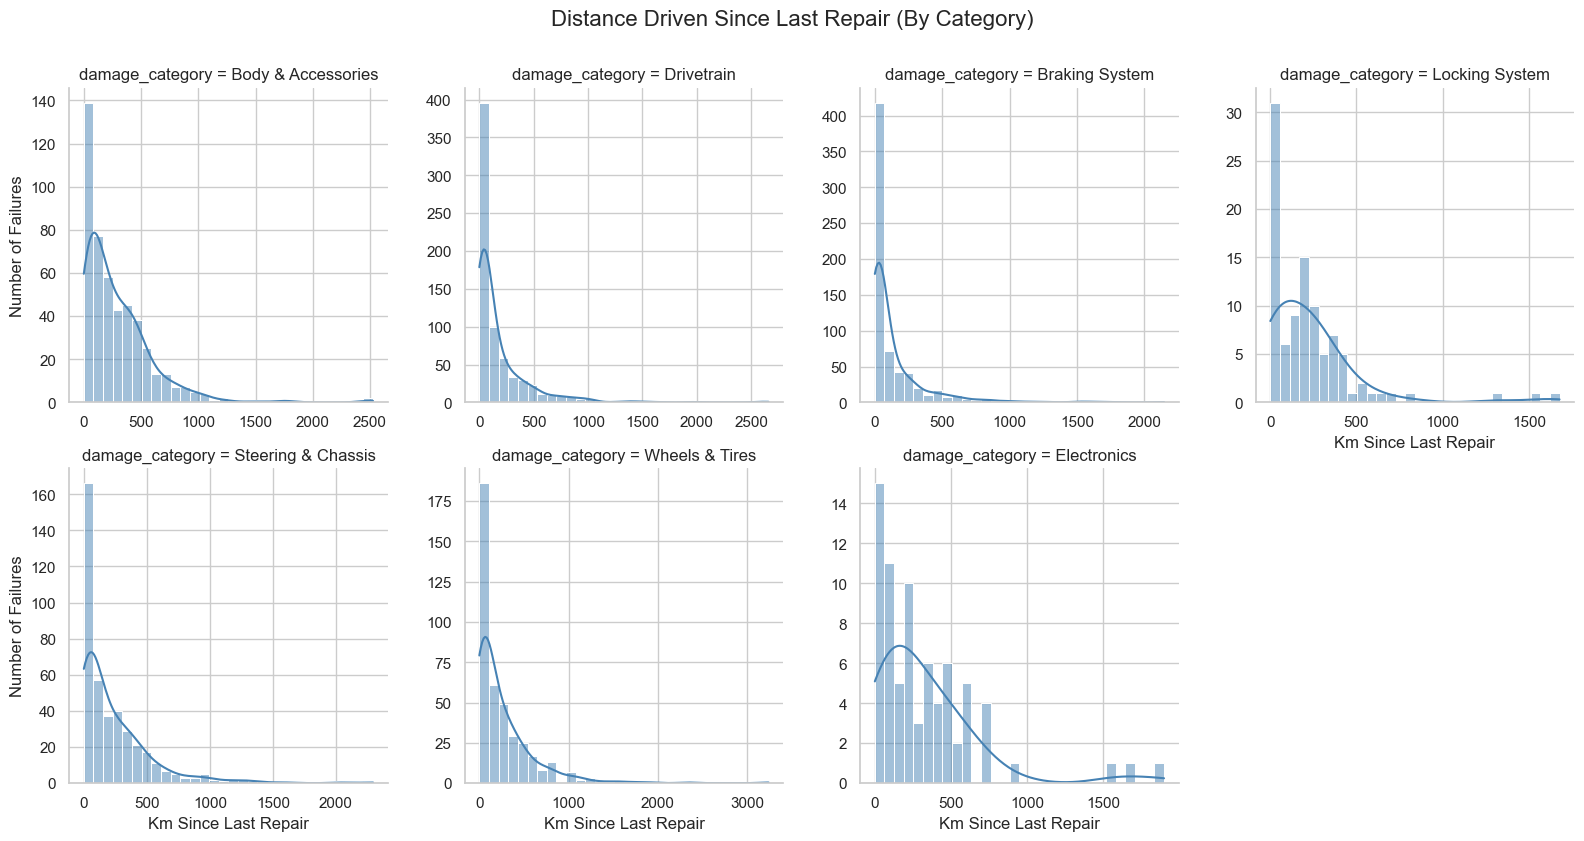

In [926]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean style for the plots
sns.set_theme(style="whitegrid")

# Filter out the 'event_observed == 0' rows if you only want to look at ACTUAL broken parts
# (We don't want the artificially created survivors skewing our raw failure histograms)
actual_failures = damage_with_usage[damage_with_usage['event_observed'] == 1].copy()

# =====================================================================
# PLOT 1: The "Wear-and-Tear" Profile (Grid of Histograms)
# =====================================================================
g = sns.FacetGrid(actual_failures, col="damage_category", col_wrap=4, height=4, sharex=False, sharey=False)
g.map_dataframe(sns.histplot, x="km_since_last_failure", bins=30, color="steelblue", kde=True)
g.fig.suptitle('Distance Driven Since Last Repair (By Category)', y=1.05, fontsize=16)
g.set_axis_labels("Km Since Last Repair", "Number of Failures")
plt.show()

### The "Aging Fleet" Profile

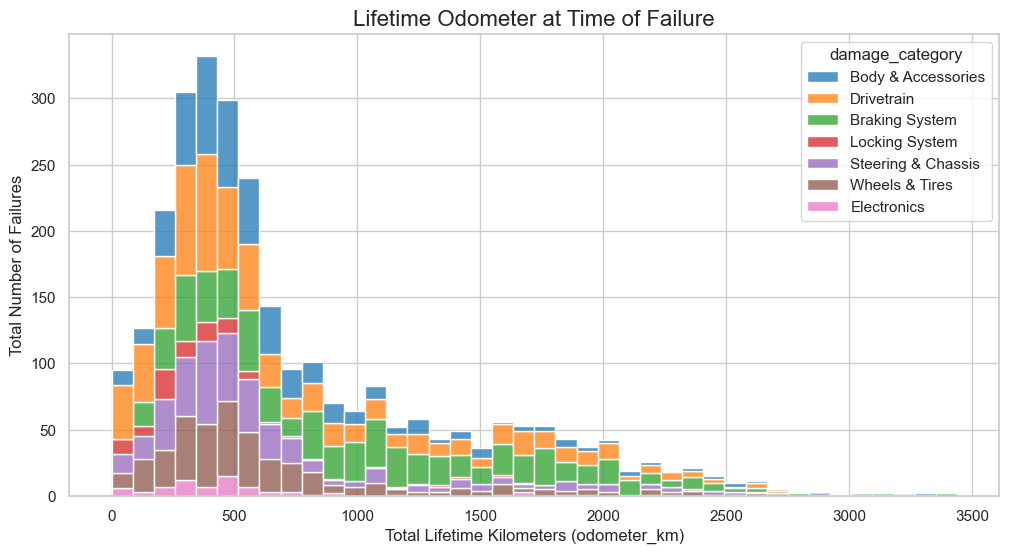

In [927]:
plt.figure(figsize=(12, 6))
sns.histplot(
    data=actual_failures, 
    x="odometer_km", 
    hue="damage_category", 
    multiple="stack", # Stacks the colors on top of each other
    bins=40,
    palette="tab10"
)
plt.title('Lifetime Odometer at Time of Failure', fontsize=16)
plt.xlabel('Total Lifetime Kilometers (odometer_km)')
plt.ylabel('Total Number of Failures')
plt.show()

### The "Operational Rhythm"

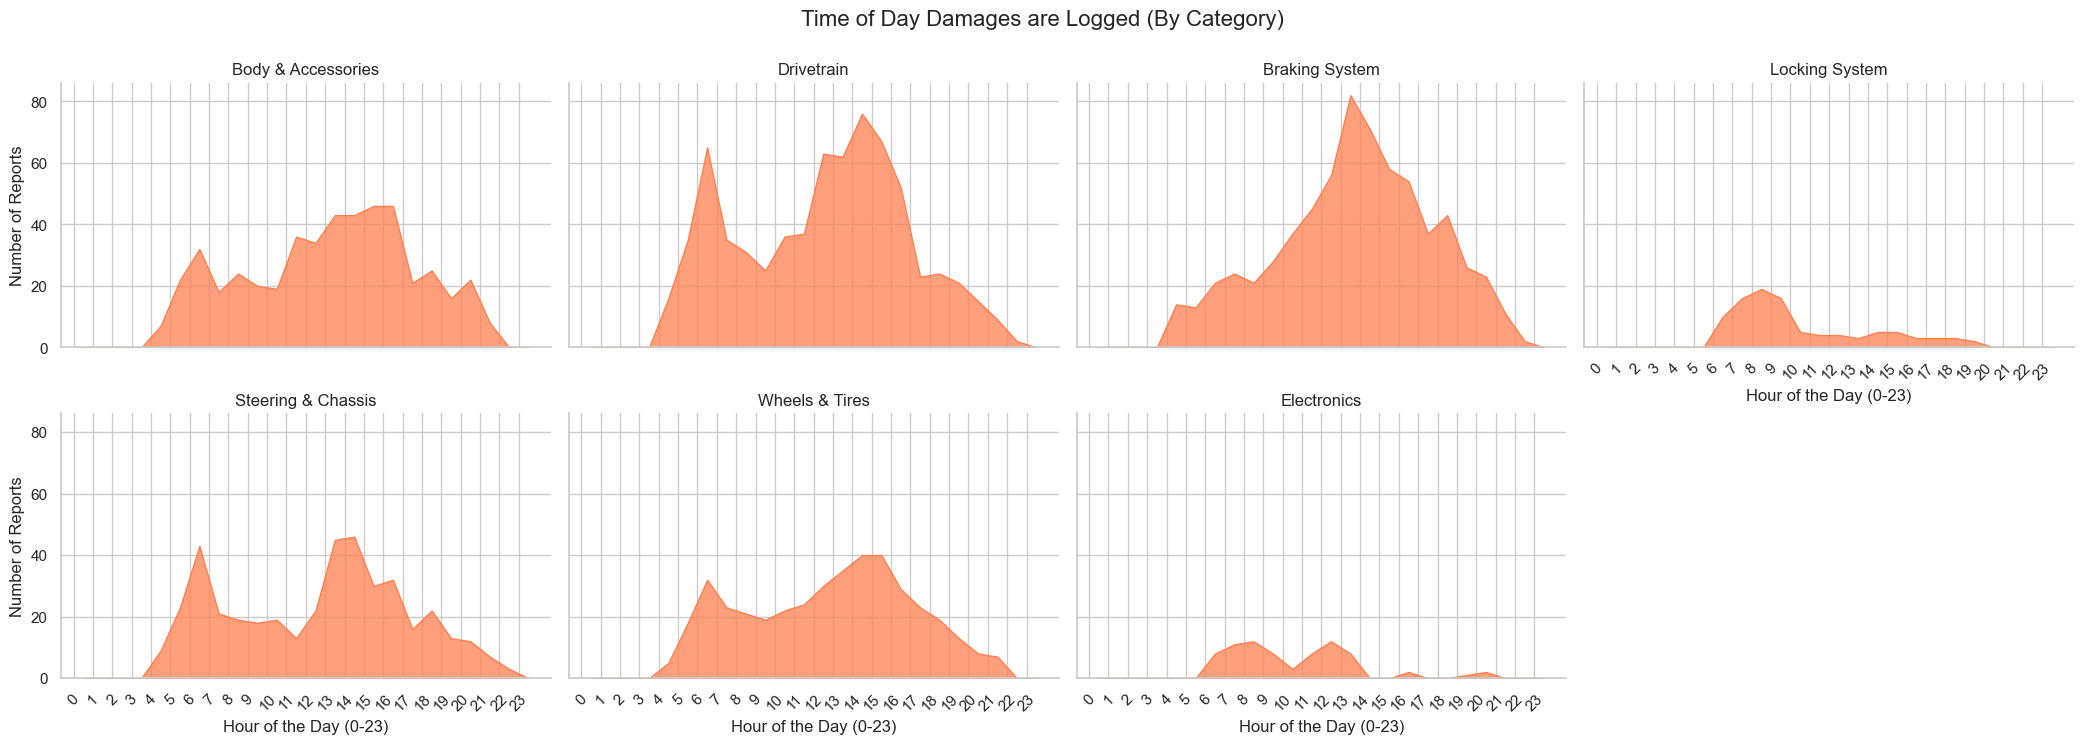

In [928]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean style
sns.set_theme(style="whitegrid")

# (Assuming actual_failures is already defined)

# =====================================================================
# PLOT 3: The "Operational Rhythm" (Separated by Category)
# =====================================================================
g = sns.displot(
    data=actual_failures, 
    x="created_hour", 
    col="damage_category", 
    col_wrap=4,           # Puts 4 plots on each row
    kind="hist", 
    element="poly",       # Keeps your preferred polygon style
    bins=24,
    binrange=(0, 24),     # Forces the x-axis to cover exactly 0 to 24 hours
    height=3.5,           # Made slightly taller for better visibility
    aspect=1.5,           # Width-to-height ratio of subplots
    color="coral"         
)

# Formatting the overall figure
g.fig.suptitle('Time of Day Damages are Logged (By Category)', y=1.05, fontsize=16)
g.set_axis_labels("Hour of the Day (0-23)", "Number of Reports")

# Force x-axis to show EVERY single hour
g.set(xticks=range(0, 24))

# Rotate the x-axis labels slightly so the 24 numbers don't overlap
for ax in g.axes.flat:
    ax.tick_params(axis='x', labelrotation=45)

# Clean up subplot titles
g.set_titles(col_template="{col_name}")

plt.show()

### The "Cycle-Wear" Profile

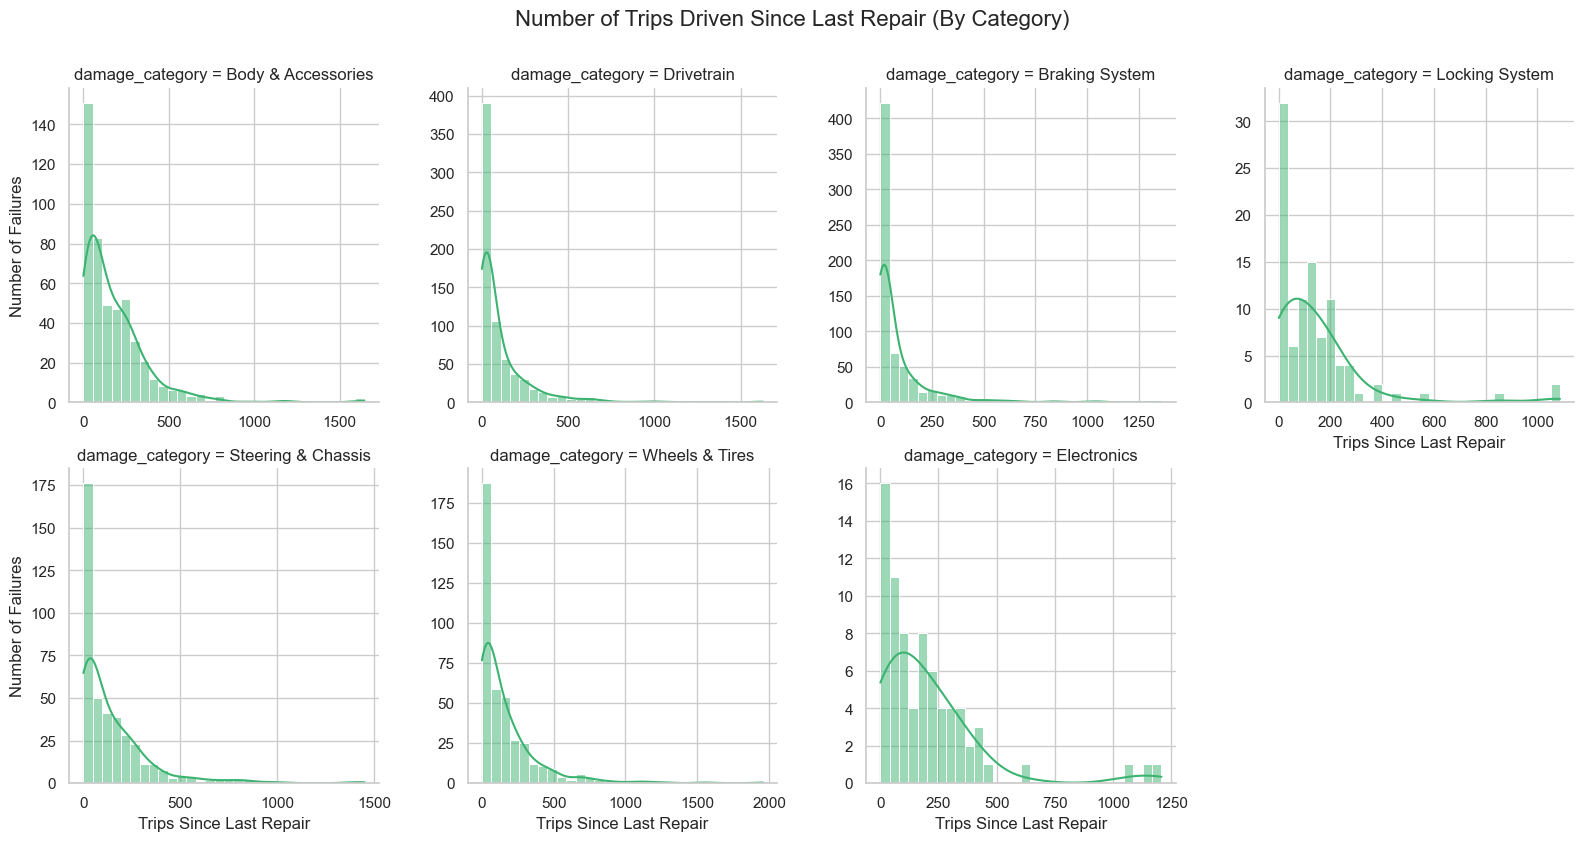

In [929]:
g = sns.FacetGrid(actual_failures, col="damage_category", col_wrap=4, height=4, sharex=False, sharey=False)

# Using a distinct color (mediumseagreen) so you don't confuse it with the distance plots!
g.map_dataframe(sns.histplot, x="trips_since_last_failure", bins=30, color="mediumseagreen", kde=True)

g.fig.suptitle('Number of Trips Driven Since Last Repair (By Category)', y=1.05, fontsize=16)
g.set_axis_labels("Trips Since Last Repair", "Number of Failures")

## Adding in surviving parts

Adding back in surviving parts for the Weibull dstribution to not exclude parts with longer lifelines from the calcultionof mean time to failure and median survival times
In damage_with_usage, each row corresponds to damages, but in the final_weibull_data we add back in the healthy part of the fleet

In [930]:
"""# ==============================================================================
# NEW CODE GOES HERE: ADDING RIGHT-CENSORED (SURVIVOR) DATA
# ==============================================================================

print("\n" + "="*60)
print("GENERATING RIGHT-CENSORED (SURVIVOR) DATA")
print("="*60)

# 1. Mark existing failures as events (1 = failure observed)
#damage_with_usage['event_observed'] = 1

# 2. Get the current max odometer reading for EVERY vehicle from usage_ref
current_fleet_status = usage_ref.groupby('vehicle_id')['odometer_km'].max()

survivor_rows_list = []
unique_categories = damage_with_usage['damage_category'].unique()

for category in unique_categories:
    
    # Get the vehicles that have had a failure in this specific category
    cat_failures = damage_with_usage[damage_with_usage['damage_category'] == category]
    
    # --- GROUP A: Vehicles that HAVE failed in this category before ---
    # Find distance driven SINCE their last failure up to their current max odometer
    last_failure_odo = cat_failures.groupby('vehicle_id')['odometer_km'].max()
    common_vehicles = last_failure_odo.index.intersection(current_fleet_status.index)
    dist_since_last = current_fleet_status.loc[common_vehicles] - last_failure_odo.loc[common_vehicles]
    
    survivors_A = pd.DataFrame({
        'vehicle_id': dist_since_last.index,
        'damage_category': category,
        'km_since_last_failure': dist_since_last.values,
        'event_observed': 0  # 0 = censored (survived without failure)
    })
    
    # --- GROUP B: Vehicles that have NEVER failed in this category ---
    # Find distance driven from 0 up to their current max odometer
    never_failed_ids = current_fleet_status.index.difference(last_failure_odo.index)
    survivors_B = pd.DataFrame({
        'vehicle_id': never_failed_ids,
        'damage_category': category,
        'km_since_last_failure': current_fleet_status.loc[never_failed_ids].values,
        'event_observed': 0
    })
    
    survivor_rows_list.extend([survivors_A, survivors_B])

# 3. Combine survivors
survivors_df = pd.concat(survivor_rows_list, ignore_index=True)
# Filter out 0km survivors to avoid math errors in Weibull
survivors_df = survivors_df[survivors_df['km_since_last_failure'] > 0].copy()

# 4. Create the FINAL dataset combining failures and survivors
final_weibull_data = pd.concat([
    damage_with_usage[['damage_category', 'km_since_last_failure', 'event_observed']],
    survivors_df[['damage_category', 'km_since_last_failure', 'event_observed']]
], ignore_index=True)

print(f"Original Failures: {len(damage_with_usage):,}")
print(f"Added Survivors:   {len(survivors_df):,} (Right Censored)")
print(f"Total Datapoints:  {len(final_weibull_data):,}")"""

# ==============================================================================
# UPDATED SURVIVOR GENERATION: 2023-2024 LOOKBACK
# ==============================================================================

print("\n" + "="*60)
print("GENERATING RIGHT-CENSORED (SURVIVOR) DATA")
print("="*60)

# 1. Get current max odometer for EVERY vehicle (the "End of the Story" point)
current_fleet_status = usage_ref.groupby('vehicle_id')['odometer_km'].max()

survivor_rows_list = []

# Use categories from the mapped damage_data
unique_categories = [c for c in damage_data['damage_category'].unique() 
                     if c not in ['Other', 'Logic/User Error', 'Security Flag', 'External Factor']]

for category in unique_categories:
    
    # --- CRITICAL CHANGE ---
    # We look at ALL history (2023+2024) to find the absolute last failure.
    # We use 'damage_data' here because 'damage_with_usage' was filtered to 2024 only.
    cat_history = damage_data[damage_data['damage_category'] == category]
    
    # Get the last known odometer reading for a failure in this category per bike
    last_failure_odo = cat_history.groupby('vehicle_id')['odometer_km'].max()
    
    # --- GROUP A: Vehicles that HAVE failed in this category (in 2023 or 2024) ---
    # We calculate distance from their LAST repair ever recorded up to today.
    common_vehicles = last_failure_odo.index.intersection(current_fleet_status.index)
    dist_since_last = current_fleet_status.loc[common_vehicles] - last_failure_odo.loc[common_vehicles]
    
    survivors_A = pd.DataFrame({
        'vehicle_id': dist_since_last.index,
        'damage_category': category,
        'km_since_last_failure': dist_since_last.values,
        'event_observed': 0  # Still surviving
    })
    
    # --- GROUP B: Vehicles that have NEVER failed in this category (since Jan 2023) ---
    # These are bikes that exist in the fleet but never appeared in 'cat_history'
    never_failed_ids = current_fleet_status.index.difference(last_failure_odo.index)
    
    survivors_B = pd.DataFrame({
        'vehicle_id': never_failed_ids,
        'damage_category': category,
        'km_since_last_failure': current_fleet_status.loc[never_failed_ids].values,
        'event_observed': 0
    })
    
    survivor_rows_list.extend([survivors_A, survivors_B])

# 3. Combine survivors
survivors_df = pd.concat(survivor_rows_list, ignore_index=True)

# Filter out 0km survivors to avoid math errors
survivors_df = survivors_df[survivors_df['km_since_last_failure'] > 0].copy()

# 4. Create the FINAL dataset
# Combine the 2024 failures with these properly calculated survivors
final_weibull_data = pd.concat([
    damage_with_usage[['damage_category', 'km_since_last_failure', 'event_observed']],
    survivors_df[['damage_category', 'km_since_last_failure', 'event_observed']]
], ignore_index=True)

print(f"2024 Observed Failures: {len(damage_with_usage):,}")
print(f"Added Survivors:        {len(survivors_df):,} (Lookback 2023-2024)")
print(f"Total Combined Points:  {len(final_weibull_data):,}")


GENERATING RIGHT-CENSORED (SURVIVOR) DATA
2024 Observed Failures: 4,060
Added Survivors:        4,579 (Lookback 2023-2024)
Total Combined Points:  8,639


# Fit Weibull distribution

## Comparison of old and new weibull distribution

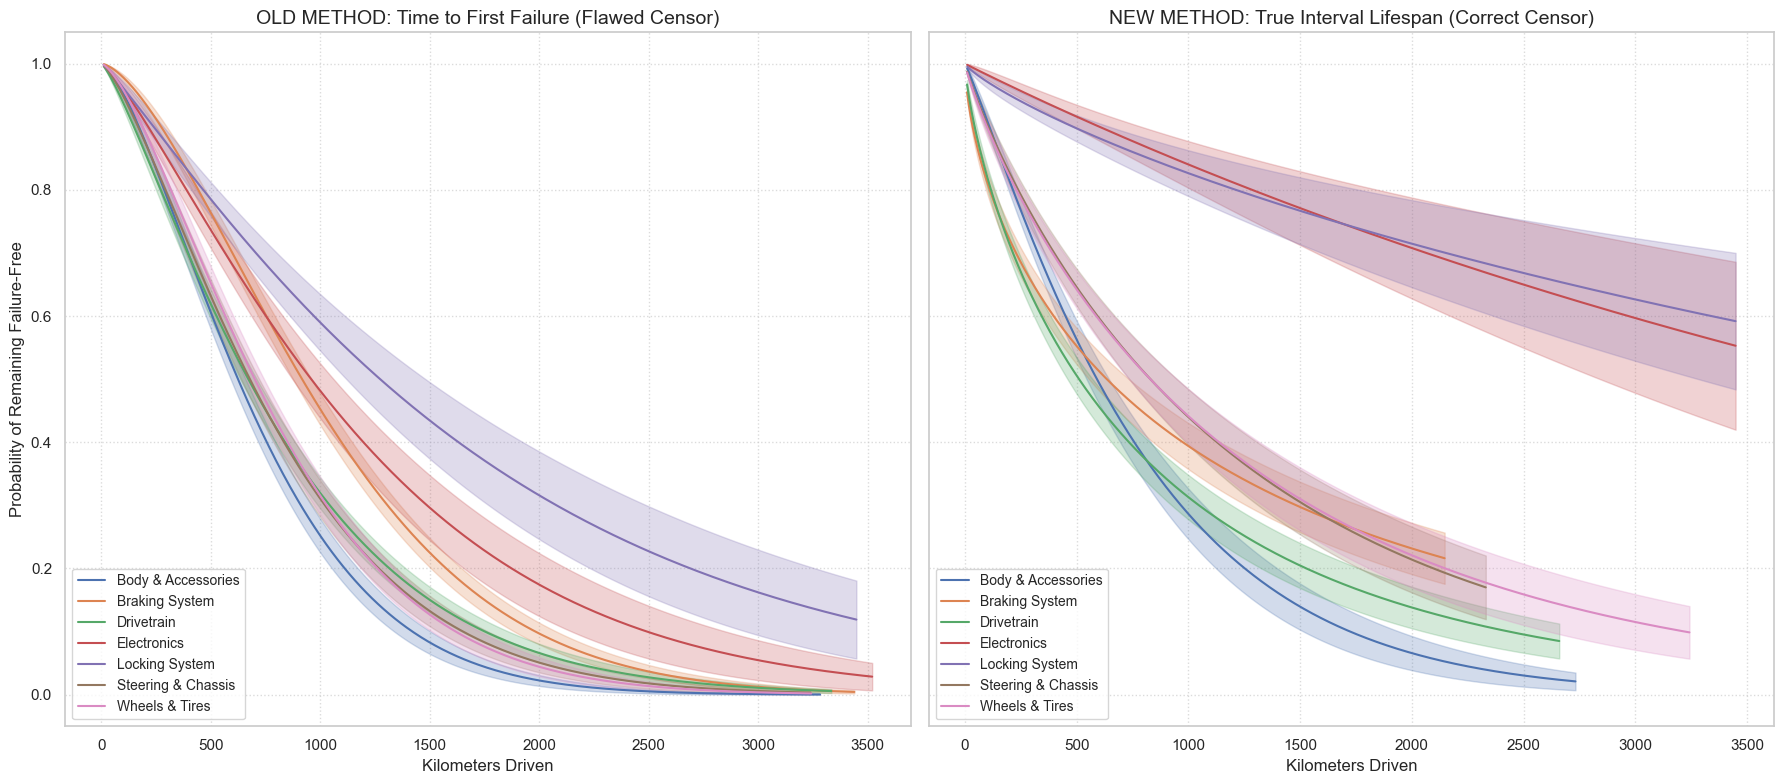


                       SIMULATOR METRICS: OLD VS NEW AVERAGE LIFESPANS (MEDIAN & MTTF)                        
+--------------------+---------+--------------+------------+---------+--------------+------------+---------------+
| Category           |   Old N |   Old Median |   Old MTTF |   New N |   New Median |   New MTTF |   Diff (MTTF) |
|--------------------+---------+--------------+------------+---------+--------------+------------+---------------|
| Body & Accessories |     986 |        624.3 |      727.0 |    1259 |        591.3 |      786.0 |          59.0 |
| Drivetrain         |    1242 |        671.4 |      837.8 |    1341 |        511.2 |      960.6 |         122.7 |
| Steering & Chassis |     992 |        678.6 |      816.6 |    1176 |        830.3 |     1300.2 |         483.6 |
| Wheels & Tires     |     976 |        700.8 |      821.7 |    1140 |        829.9 |     1333.5 |         511.8 |
| Braking System     |    1281 |        917.0 |     1043.1 |    1351 |        635.4

In [931]:
import math
import pandas as pd
import numpy as np
from lifelines import WeibullFitter
import matplotlib.pyplot as plt
from tabulate import tabulate

# 1. Setup Data & Plots
fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=True)

old_weibull_results = []
new_weibull_results = []

fleet_max_km = usage_ref.groupby('vehicle_id')['odometer_km'].max()
categories = [c for c in damage_with_usage['damage_category'].unique() 
              if c not in ['Other', 'Logic/User Error', 'Security Flag', 'External Factor']]

# 2. Loop Through Categories for Both Methods
for cat_name in categories:
    
    # =========================================================
    # METHOD 1: THE OLD WAY (From your original code)
    # =========================================================
    cat_failures_old = damage_with_usage[damage_with_usage['damage_category'] == cat_name].copy()
    cat_failures_old['age_at_failure'] = cat_failures_old['odometer_km']
    cat_failures_old = cat_failures_old[cat_failures_old['age_at_failure'] > 10.0]
    
    if len(cat_failures_old) >= 5:
        df_failures_old = pd.DataFrame({'km': cat_failures_old['age_at_failure'], 'event': 1})
        
        # Only grabs Group B (never failed)
        failed_vehicles = set(cat_failures_old['vehicle_id'].unique())
        censored_vehicles = set(fleet_max_km.index) - failed_vehicles
        df_censored_old = pd.DataFrame({'km': fleet_max_km[list(censored_vehicles)].values, 'event': 0})
        df_censored_old = df_censored_old[df_censored_old['km'] > 10.0]
        
        df_fit_old = pd.concat([df_failures_old, df_censored_old])
        
        wf_old = WeibullFitter()
        try:
            wf_old.fit(df_fit_old['km'], event_observed=df_fit_old['event'], label=cat_name)
            wf_old.plot_survival_function(ax=axes[0])
            old_weibull_results.append({
                'Category': cat_name,
                'Old_Shape': wf_old.rho_,
                'Old_Scale': wf_old.lambda_,
                'Old_Data_Points': len(df_fit_old)
            })
        except Exception:
            pass

    # =========================================================
    # METHOD 2: THE NEW WAY (Using final_weibull_data)
    # =========================================================
    df_new = final_weibull_data[final_weibull_data['damage_category'] == cat_name].copy()
    
    # Filter noise to match the old logic
    df_new = df_new[df_new['km_since_last_failure'] > 10.0]
    
    # Check if we have enough actual failure events (1s) to fit a curve
    if len(df_new[df_new['event_observed'] == 1]) >= 5:
        wf_new = WeibullFitter()
        try:
            wf_new.fit(df_new['km_since_last_failure'], event_observed=df_new['event_observed'], label=cat_name)
            wf_new.plot_survival_function(ax=axes[1])
            new_weibull_results.append({
                'Category': cat_name,
                'New_Shape': wf_new.rho_,
                'New_Scale': wf_new.lambda_,
                'New_Data_Points': len(df_new)
            })
        except Exception:
            pass

# 3. Format Plots
axes[0].set_title('OLD METHOD: Time to First Failure (Flawed Censor)', fontsize=14)
axes[1].set_title('NEW METHOD: True Interval Lifespan (Correct Censor)', fontsize=14)

for ax in axes:
    ax.set_xlabel('Kilometers Driven')
    ax.set_ylabel('Probability of Remaining Failure-Free')
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.legend(loc='lower left', fontsize='small')

plt.tight_layout()
plt.show()

# 4. Calculate Median (B50) Life and MTTF and Compare
df_old = pd.DataFrame(old_weibull_results)
if not df_old.empty:
    # Median Life (B50)
    df_old['Old_Median_km'] = df_old.apply(
        lambda r: r['Old_Scale'] * ((-math.log(0.50))**(1/r['Old_Shape'])), axis=1
    )
    # Mean Time To Failure (MTTF)
    df_old['Old_MTTF_km'] = df_old.apply(
        lambda r: r['Old_Scale'] * math.gamma(1 + (1/r['Old_Shape'])), axis=1
    )

df_new = pd.DataFrame(new_weibull_results)
if not df_new.empty:
    # Median Life (B50)
    df_new['New_Median_km'] = df_new.apply(
        lambda r: r['New_Scale'] * ((-math.log(0.50))**(1/r['New_Shape'])), axis=1
    )
    # Mean Time To Failure (MTTF)
    df_new['New_MTTF_km'] = df_new.apply(
        lambda r: r['New_Scale'] * math.gamma(1 + (1/r['New_Shape'])), axis=1
    )

# Merge tables for a clean side-by-side comparison
if not df_old.empty and not df_new.empty:
    comparison_df = pd.merge(
        df_old[['Category', 'Old_Data_Points', 'Old_Median_km', 'Old_MTTF_km']], 
        df_new[['Category', 'New_Data_Points', 'New_Median_km', 'New_MTTF_km']], 
        on='Category', 
        how='inner'
    )
    
    # Calculate how much the calculation improved
    comparison_df['Diff_MTTF_km'] = comparison_df['New_MTTF_km'] - comparison_df['Old_MTTF_km']
    comparison_df = comparison_df.sort_values('New_MTTF_km')
    
    print("\n" + "="*110)
    print(f"{'SIMULATOR METRICS: OLD VS NEW AVERAGE LIFESPANS (MEDIAN & MTTF)':^110}")
    print("="*110)
    
    display_headers = [
        'Category', 'Old N', 'Old Median', 'Old MTTF', 
        'New N', 'New Median', 'New MTTF', 'Diff (MTTF)'
    ]
    
    print(tabulate(
        comparison_df, 
        headers=display_headers, 
        tablefmt='psql', 
        showindex=False, 
        floatfmt=".1f"
    ))

## NEW Weibull fitter

(ADDING IN SURVIVORS)
This formulation uses the lifeline python package for calculating and plotting the Probability Density Function (PDF)

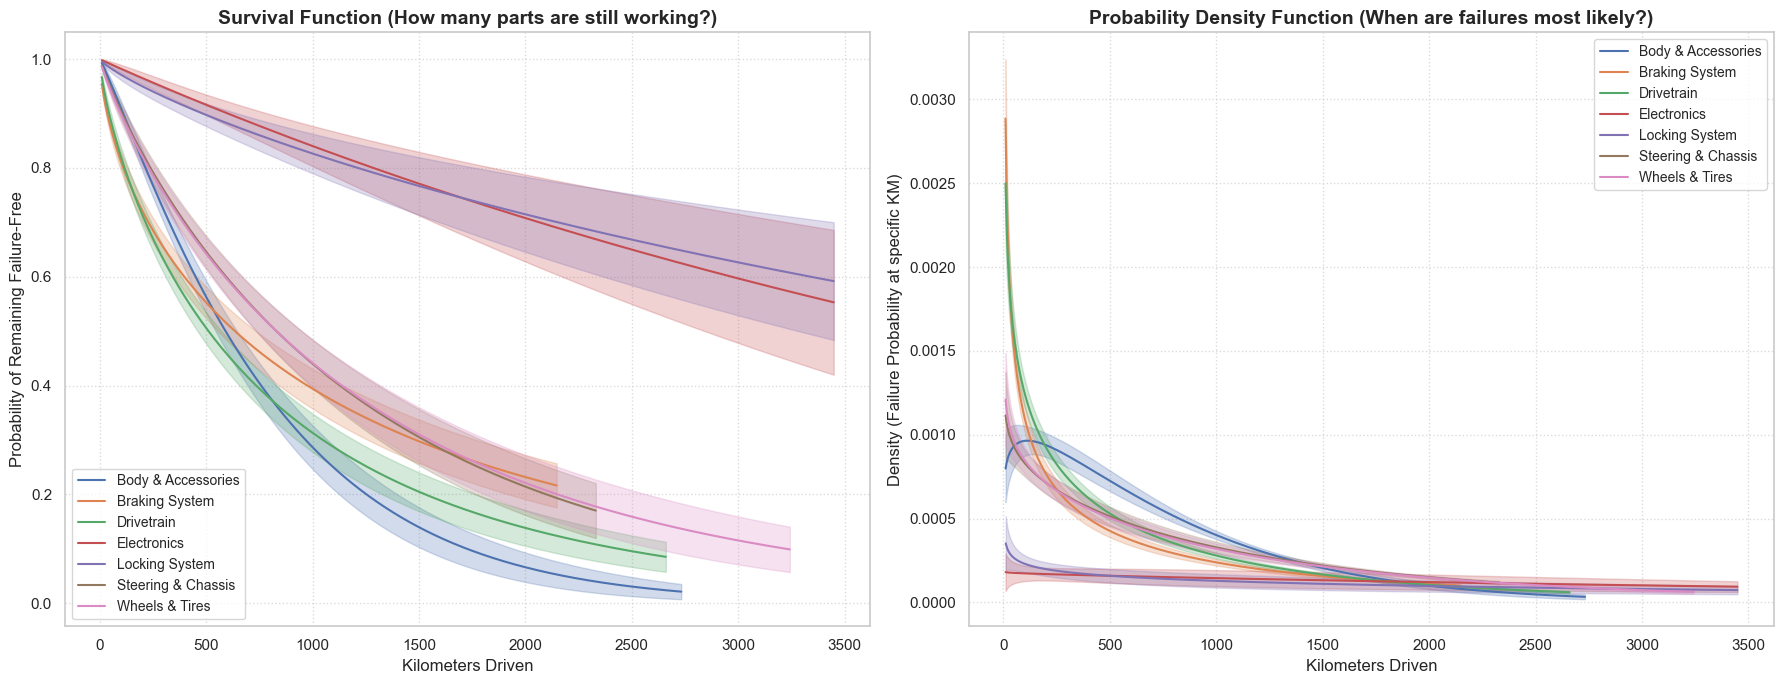


                             SIMULATOR METRICS: AVERAGE LIFESPANS (MEDIAN & MTTF)                             
COLUMN EXPLANATIONS:
- Category:        The specific physical component or system on the bike being analyzed.
- Shape (ρ):       Dictates how it fails; > 1 means it wears out over time, ~1 means failures are random.
- Scale (λ):       The curve's 'characteristic life' where approximately 63.2% of these parts will have failed.
- Data Points (N): The total number of observed failures AND working survivors in the model.
- Median (km):     The exact distance at which 50% of the parts are expected to have failed.
- MTTF (km):       The Mean Time To Failure (True mathematical average lifespan).
--------------------------------------------------------------------------------------------------------------
+--------------------+-------------+-------------+-------------------+---------------+-------------+
| Category           |   Shape (ρ) |   Scale (λ) |   Data Points (N) |   Median 

In [932]:
# THIS IS ONLY THE NEW METHOD (USING THE DATA SET WITH THE ADDED SURVIVORS)
import math
import pandas as pd
import numpy as np
from lifelines import WeibullFitter
import matplotlib.pyplot as plt
from tabulate import tabulate

# 1. Setup Data & Plot
fig, axes = plt.subplots(1, 2, figsize=(18, 7)) 

weibull_results = []

# Filtering out logic/external categories for the reliability study
categories = [c for c in damage_with_usage['damage_category'].unique() 
              if c not in ['Other', 'Logic/User Error', 'Security Flag', 'External Factor']]

# 2. Loop Through Categories
for cat_name in categories:
    
    # Extract the corrected, right-censored dataset
    df_fit = final_weibull_data[final_weibull_data['damage_category'] == cat_name].copy()
    
    # Filter noise (e.g., immediate duplicate logs)
    df_fit = df_fit[df_fit['km_since_last_failure'] > 10.0]
    
    # Check if we have enough actual failure events (1s) to fit a reliable curve
    if len(df_fit[df_fit['event_observed'] == 1]) >= 5:
        wf = WeibullFitter()
        try:
            # Fitting to 'km_since_last_failure' is the "True Interval" method
            wf.fit(df_fit['km_since_last_failure'], event_observed=df_fit['event_observed'], label=cat_name)
        
            # Plot 1: Survival on the left (axes[0])
            wf.plot_survival_function(ax=axes[0])
            
            # Plot 2: Probability Density (PDF) on the right (axes[1])
            # .plot_density() is the lifelines built-in for the PDF/Bell Curve
            wf.plot_density(ax=axes[1])
            
            # Store the parameters for the simulator
            weibull_results.append({
                'Category': cat_name,
                'Shape (ρ)': wf.rho_,
                'Scale (λ)': wf.lambda_,
                'Data Points (N)': len(df_fit)
            })
        except Exception as e:
            print(f"Skipping {cat_name}: {e}")

# --- Format Plots ---
axes[0].set_title('Survival Function (How many parts are still working?)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Kilometers Driven')
axes[0].set_ylabel('Probability of Remaining Failure-Free')
axes[0].grid(True, linestyle=':', alpha=0.7)
axes[0].legend(loc='lower left', fontsize='small')

axes[1].set_title('Probability Density Function (When are failures most likely?)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Kilometers Driven')
axes[1].set_ylabel('Density (Failure Probability at specific KM)')
axes[1].grid(True, linestyle=':', alpha=0.7)
axes[1].legend(loc='upper right', fontsize='small')

plt.tight_layout()
plt.show()

# 4. Calculate Median (B50) Life and MTTF
df_results = pd.DataFrame(weibull_results)

if not df_results.empty:
    # Median Life (B50)
    df_results['Median (km)'] = df_results.apply(
        lambda r: r['Scale (λ)'] * ((-math.log(0.50))**(1/r['Shape (ρ)'])), axis=1
    )
    # Mean Time To Failure (MTTF)
    df_results['MTTF (km)'] = df_results.apply(
        lambda r: r['Scale (λ)'] * math.gamma(1 + (1/r['Shape (ρ)'])), axis=1
    )

    # Sort by the average lifespan for logical reading
    df_results = df_results.sort_values('MTTF (km)')
    
    # --- FINAL PROFESSIONAL PRINTOUT ---
    print("\n" + "="*110)
    print(f"{'SIMULATOR METRICS: AVERAGE LIFESPANS (MEDIAN & MTTF)':^110}")
    print("="*110)
    print("COLUMN EXPLANATIONS:")
    print("- Category:        The specific physical component or system on the bike being analyzed.")
    print("- Shape (ρ):       Dictates how it fails; > 1 means it wears out over time, ~1 means failures are random.")
    print("- Scale (λ):       The curve's 'characteristic life' where approximately 63.2% of these parts will have failed.")
    print("- Data Points (N): The total number of observed failures AND working survivors in the model.")
    print("- Median (km):     The exact distance at which 50% of the parts are expected to have failed.")
    print("- MTTF (km):       The Mean Time To Failure (True mathematical average lifespan).")
    print("-" * 110)
    
    print(tabulate(
        df_results, 
        headers='keys', 
        tablefmt='psql', 
        showindex=False, 
        floatfmt=".2f"
    ))
    print("-" * 110)

### with manual PDF calculation


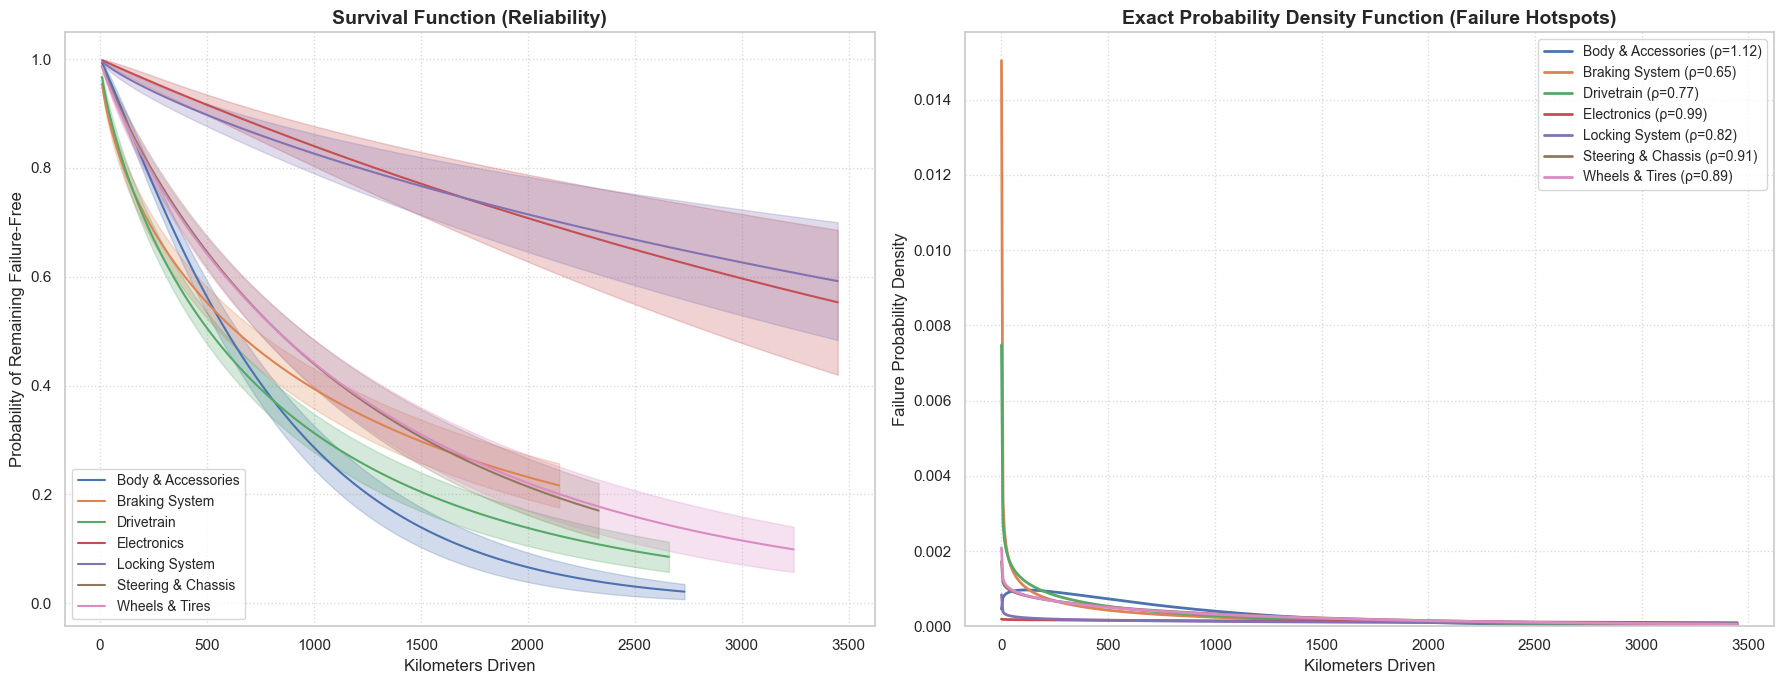


                             SIMULATOR METRICS: AVERAGE LIFESPANS (MEDIAN & MTTF)                             
+--------------------+-------------+-------------+-------------------+---------------+-------------+
| Category           |   Shape (ρ) |   Scale (λ) |   Data Points (N) |   Median (km) |   MTTF (km) |
|--------------------+-------------+-------------+-------------------+---------------+-------------|
| Body & Accessories |        1.12 |      819.75 |              1259 |        591.29 |      786.01 |
| Drivetrain         |        0.77 |      823.25 |              1341 |        511.20 |      960.55 |
| Steering & Chassis |        0.91 |     1242.53 |              1176 |        830.29 |     1300.23 |
| Wheels & Tires     |        0.89 |     1255.59 |              1140 |        829.86 |     1333.47 |
| Braking System     |        0.65 |     1115.61 |              1351 |        635.40 |     1521.37 |
| Electronics        |        0.99 |     5852.34 |               905 |       404

In [933]:
# THIS IS ONLY THE NEW METHOD (USING THE DATA SET WITH THE ADDED SURVIVORS)
import math
import pandas as pd
import numpy as np
from lifelines import WeibullFitter
import matplotlib.pyplot as plt
from tabulate import tabulate

# 1. Setup Data & Plot
fig, axes = plt.subplots(1, 2, figsize=(18, 7)) 

weibull_results = []

# Define x-range for the PDF plot (e.g., from 0 to 5000km)
x_max = final_weibull_data['km_since_last_failure'].max()
x_range = np.linspace(0.1, x_max, 500) # Start at 0.1 to avoid division by zero

# Filtering out logic/external categories for the reliability study
categories = [c for c in final_weibull_data['damage_category'].unique() 
              if c not in ['Other', 'Logic/User Error', 'Security Flag', 'External Factor']]

# 2. Loop Through Categories
for cat_name in categories:
    
    # Extract the corrected, right-censored dataset
    df_fit = final_weibull_data[final_weibull_data['damage_category'] == cat_name].copy()
    
    # Filter noise
    df_fit = df_fit[df_fit['km_since_last_failure'] > 10.0]
    
    if len(df_fit[df_fit['event_observed'] == 1]) >= 5:
        wf = WeibullFitter()
        try:
            wf.fit(df_fit['km_since_last_failure'], event_observed=df_fit['event_observed'], label=cat_name)
        
            # Plot 1: Survival on the left
            wf.plot_survival_function(ax=axes[0])
            
            # --- MANUAL PDF CALCULATION ---
            rho = wf.rho_
            lmbda = wf.lambda_
            
            # f(t) = (rho/lmbda) * (t/lmbda)**(rho-1) * exp(-(t/lmbda)**rho)
            pdf_values = (rho / lmbda) * (x_range / lmbda)**(rho - 1) * np.exp(-(x_range / lmbda)**rho)
            
            axes[1].plot(x_range, pdf_values, label=f"{cat_name} (ρ={rho:.2f})", lw=2)
            
            # Store the parameters
            weibull_results.append({
                'Category': cat_name,
                'Shape (ρ)': rho,
                'Scale (λ)': lmbda,
                'Data Points (N)': len(df_fit)
            })
        except Exception as e:
            print(f"Skipping {cat_name}: {e}")

# --- Format Plots ---
axes[0].set_title('Survival Function (Reliability)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Kilometers Driven')
axes[0].set_ylabel('Probability of Remaining Failure-Free')
axes[0].grid(True, linestyle=':', alpha=0.7)
axes[0].legend(loc='lower left', fontsize='small')

axes[1].set_title('Exact Probability Density Function (Failure Hotspots)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Kilometers Driven')
axes[1].set_ylabel('Failure Probability Density')
axes[1].grid(True, linestyle=':', alpha=0.7)
axes[1].legend(loc='upper right', fontsize='small')
axes[1].set_ylim(bottom=0)

plt.tight_layout()
plt.show()

# 4. Final Reporting
df_results = pd.DataFrame(weibull_results)

if not df_results.empty:
    df_results['Median (km)'] = df_results.apply(
        lambda r: r['Scale (λ)'] * ((-math.log(0.50))**(1/r['Shape (ρ)'])), axis=1
    )
    df_results['MTTF (km)'] = df_results.apply(
        lambda r: r['Scale (λ)'] * math.gamma(1 + (1/r['Shape (ρ)'])), axis=1
    )

    df_results = df_results.sort_values('MTTF (km)')
    
    print("\n" + "="*110)
    print(f"{'SIMULATOR METRICS: AVERAGE LIFESPANS (MEDIAN & MTTF)':^110}")
    print("="*110)
    
    print(tabulate(
        df_results, 
        headers='keys', 
        tablefmt='psql', 
        showindex=False, 
        floatfmt=".2f"
    ))
    print("-" * 110)

## OLD Weibull fitter

(NOT ADDING SURVIVORS)
This is not learning behavior from the parts that are working. Meaning the

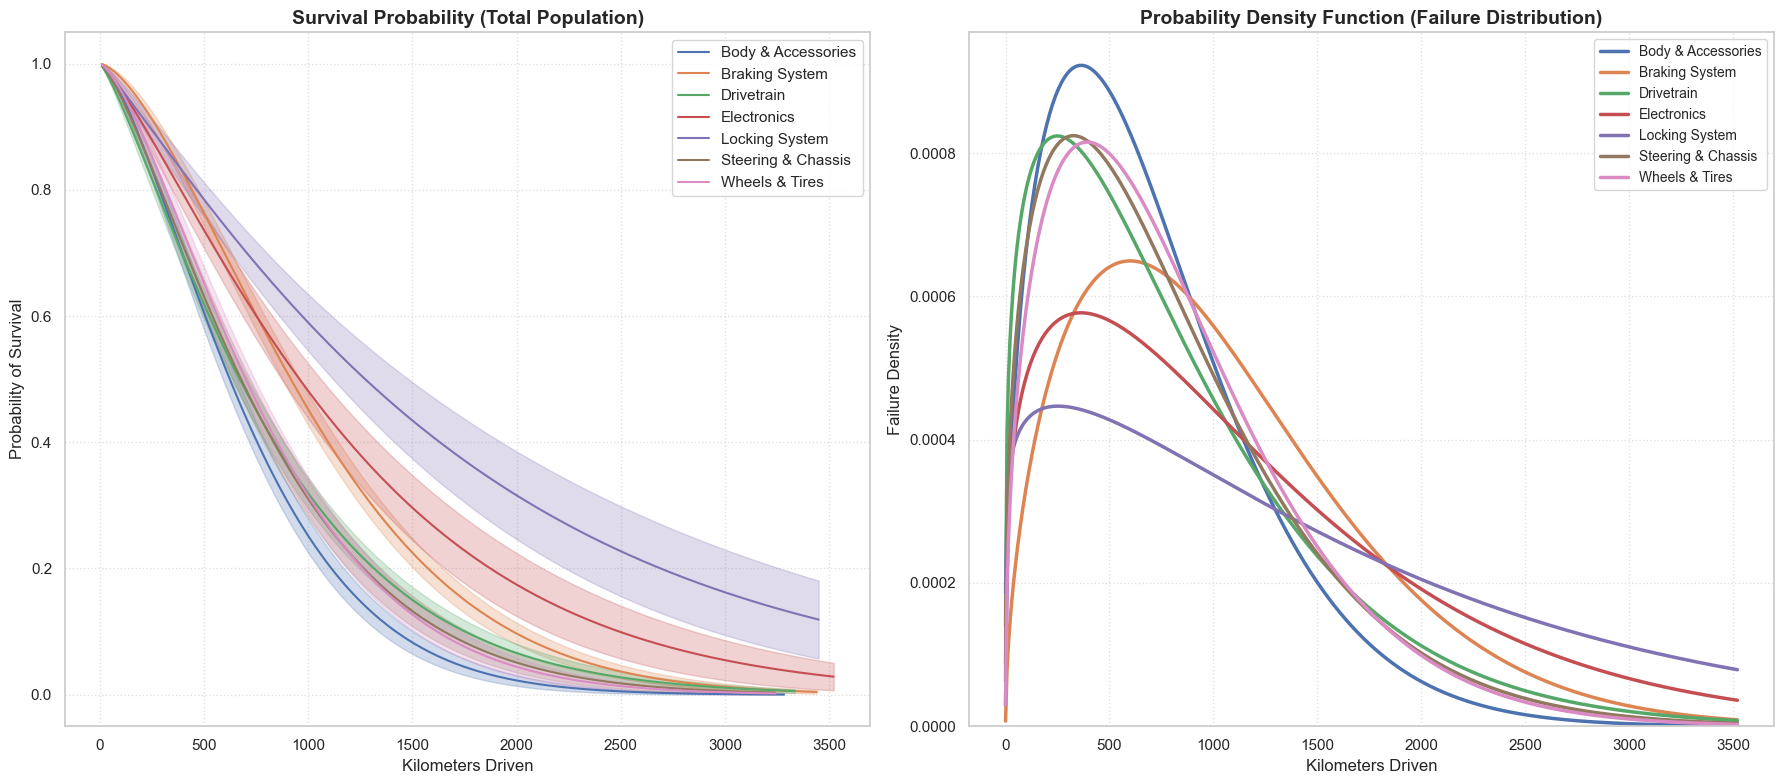


                             SIMULATOR METRICS: AVERAGE LIFESPANS (MEDIAN & MTTF)                             
COLUMN EXPLANATIONS:
- Category:        The specific physical component or system on the bike being analyzed.
- Shape (ρ):       Dictates how it fails; > 1 means it wears out over time, ~1 means failures are random.
- Scale (λ):       The curve's 'characteristic life' where % of parts will have failed.
- Data Points (N): Total count of observed failures AND working survivors used in calculation.
- Median (km):     The distance at which exactly 50% of the parts are expected to have failed.
- MTTF (km):       The Mean Time To Failure (mathematical average lifespan).
--------------------------------------------------------------------------------------------------------------
+--------------------+-------------+-------------+-------------------+---------------+-------------+
| Category           |   Shape (ρ) |   Scale (λ) |   Data Points (N) |   Median (km) |   MTTF (km) |
|---

In [934]:
import math
import pandas as pd
import numpy as np
from lifelines import WeibullFitter
import matplotlib.pyplot as plt
from tabulate import tabulate

# 1. Initialize Subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

weibull_results = []
fleet_max_km = usage_ref.groupby('vehicle_id')['odometer_km'].max()
categories = [c for c in damage_with_usage['damage_category'].unique() 
              if c not in ['Other', 'Logic/User Error', 'Security Flag', 'External Factor']]

# Setup for PDF plotting (0 to 5000km or max odometer)
max_x = min(usage_ref['odometer_km'].max(), 5000)
x_range = np.linspace(0.1, max_x, 500)

for cat_name in categories:
    cat_failures = damage_with_usage[damage_with_usage['damage_category'] == cat_name].copy()
    cat_failures['age_at_failure'] = cat_failures['odometer_km']
    cat_failures = cat_failures[cat_failures['age_at_failure'] > 10.0]
    
    if len(cat_failures) < 5:
        continue

    df_failures = pd.DataFrame({'km': cat_failures['age_at_failure'], 'event': 1})
    failed_vehicles = set(cat_failures['vehicle_id'].unique())
    censored_vehicles = set(fleet_max_km.index) - failed_vehicles

    df_censored = pd.DataFrame({
        'km': fleet_max_km[list(censored_vehicles)].values,
        'event': 0
    })
    df_censored = df_censored[df_censored['km'] > 10.0]
    df_fit = pd.concat([df_failures, df_censored])

    wf = WeibullFitter()
    try:
        wf.fit(df_fit['km'], event_observed=df_fit['event'], label=cat_name)
        
        # --- PLOT 1: Survival Function ---
        wf.plot_survival_function(ax=ax1)
        
        # --- PLOT 2: Manual PDF Calculation ---
        rho = wf.rho_
        lmbda = wf.lambda_
        pdf_values = (rho/lmbda) * (x_range/lmbda)**(rho-1) * np.exp(-(x_range/lmbda)**rho)
        ax2.plot(x_range, pdf_values, label=cat_name, lw=2.5)

        # Calculate Statistics for the Report
        median = lmbda * (math.log(2)**(1/rho))
        mttf = lmbda * math.gamma(1 + (1/rho))
        
        weibull_results.append({
            'Category': cat_name,
            'Shape (ρ)': rho,
            'Scale (λ)': lmbda,
            'Data Points (N)': len(df_fit),
            'Median (km)': median,
            'MTTF (km)': mttf
        })

    except Exception as e:
        print(f"Skipping {cat_name}: {e}")

# --- Formatting the Visuals ---
ax1.set_title('Survival Probability (Total Population)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Kilometers Driven')
ax1.set_ylabel('Probability of Survival')
ax1.grid(True, linestyle=':', alpha=0.6)

ax2.set_title('Probability Density Function (Failure Distribution)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Kilometers Driven')
ax2.set_ylabel('Failure Density')
ax2.set_ylim(bottom=0)
ax2.legend(loc='upper right', fontsize='small')
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# --- 2. GENERATE THE PROFESSIONAL REPORT ---
results_df = pd.DataFrame(weibull_results)

if not results_df.empty:
    print("\n" + "="*110)
    print(f"{'SIMULATOR METRICS: AVERAGE LIFESPANS (MEDIAN & MTTF)':^110}")
    print("="*110)
    print("COLUMN EXPLANATIONS:")
    print("- Category:        The specific physical component or system on the bike being analyzed.")
    print("- Shape (ρ):       Dictates how it fails; > 1 means it wears out over time, ~1 means failures are random.")
    print("- Scale (λ):       The curve's 'characteristic life' where % of parts will have failed.")
    print("- Data Points (N): Total count of observed failures AND working survivors used in calculation.")
    print("- Median (km):     The distance at which exactly 50% of the parts are expected to have failed.")
    print("- MTTF (km):       The Mean Time To Failure (mathematical average lifespan).")
    print("-" * 110)

    # Sort by Median life to show most vulnerable parts first
    results_df = results_df.sort_values('Median (km)')

    print(tabulate(
        results_df, 
        headers='keys', 
        tablefmt='psql', 
        showindex=False, 
        floatfmt=".2f"
    ))
    print("-" * 110)